In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import physics libraries from lib.py
from lib import (
    MaterialDatabase, 
    NuclearDatabase,
    calculate_bethe_bloch,
    calculate_capture_probability,
    calculate_specific_neutron_case,
    compare_materials_at_energy
)

# Initialize databases
material_db = MaterialDatabase()
nuclear_db = NuclearDatabase()

print("✓ All libraries and databases loaded successfully!")

✓ Particle Detectors Physics Library loaded successfully!
  - MaterialDatabase: 92 elements + 6 compounds
  - NuclearDatabase: 13 isotopes
  - Bethe-Bloch, neutron capture, and photon attenuation functions available
✓ All libraries and databases loaded successfully!


# Neutron Capture Probability Calculator

This notebook calculates the **probability of neutron capture** as a function of neutron energy for different materials, taking into account material properties and geometry.

## Features

⚛️ **Comprehensive Nuclear Database**: Includes thermal neutron cross-sections, resonance parameters, and fast neutron data for key isotopes

🎛️ **Configurable Parameters**: Easy selection of materials, density, thickness, and temperature

📊 **Multiple Plot Types**: Cross-sections, capture probabilities, thickness dependence, temperature effects

🌡️ **Temperature Effects**: Accurate 1/v law implementation with thermal motion corrections

🎯 **Interactive Analysis**: Functions for specific calculations and material comparisons

🔧 **keV Energy Units**: All energy inputs/outputs use keV for convenience (converted internally to eV for calculations)

## Key Physics

The neutron capture probability is governed by:

$$P = 1 - e^{-\Sigma t}$$

Where:
- $\Sigma = n \sigma(E)$ = macroscopic cross-section (cm⁻¹)
- $n = \frac{\rho N_A \text{abundance}}{A}$ = number density (atoms/cm³)
- $\sigma(E)$ = energy-dependent microscopic cross-section (barns)
- $t$ = material thickness (cm)

### Cross-Section Models:
- **Thermal Region** (E < 100 eV): $\sigma(E) = \sigma_{th} \sqrt{\frac{E_{th}}{E}}$ (1/v law)
- **Resonance Region** (100 eV - 500 keV): Breit-Wigner resonance peaks
- **Fast Region** (E > 500 keV): Slowly varying cross-sections

### Energy Ranges:
- **Ultra-thermal**: < 0.1 eV (< 0.0001 keV)
- **Thermal**: 0.1 eV - 100 eV (0.0001 - 0.1 keV)
- **Epithermal**: 100 eV - 500 keV (0.1 - 500 keV)
- **Fast**: > 500 keV (> 0.5 MeV)

---

**📝 Instructions**: Modify the configuration parameters, then run all cells to generate comprehensive neutron capture analysis!

**🎯 Note**: Interface uses keV units for convenience, but calculations are performed in eV internally for compatibility with physics libraries.

In [2]:
# ===================================================================
# CONFIGURATION SECTION - MODIFY THESE PARAMETERS
# ===================================================================

# Select materials/isotopes to analyze
SELECTED_MATERIALS = [
    'B-10',      # Boron-10 (high thermal capture cross-section)
    'Cd-113',    # Cadmium-113 (strong neutron absorber)
    'Gd-155',    # Gadolinium-155 (excellent thermal absorber)
    'Gd-157',    # Gadolinium-157 (highest known thermal cross-section)
    'Li-6',      # Lithium-6 (neutron converter)
    'He-3',      # Helium-3 (neutron detector gas)
    'U-235',     # Uranium-235 (fissile material)
    'H-1',       # Hydrogen (moderator)
]

# Material properties to vary
MATERIAL_DENSITIES = {
    'B-10': 2.34,       # g/cm³ (boron carbide)
    'Cd-113': 8.65,     # g/cm³ (metallic cadmium)
    'Gd-155': 7.90,     # g/cm³ (metallic gadolinium)
    'Gd-157': 7.90,     # g/cm³ (metallic gadolinium)
    'Li-6': 0.534,      # g/cm³ (metallic lithium)
    'He-3': 0.000178,   # g/cm³ (gas at STP)
    'U-235': 19.05,     # g/cm³ (metallic uranium)
    'H-1': 1.0,         # g/cm³ (water)
}

# Geometric parameters
THICKNESSES = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]  # cm
DEFAULT_THICKNESS = 1.0  # cm

# Energy range for neutrons (in keV)
ENERGY_MIN_KEV = 1e-6    # keV (ultra-cold neutrons)
ENERGY_MAX_KEV = 1e4     # keV (fast neutrons: 10 MeV)
NUM_POINTS = 1000

# Temperature for thermal neutron calculations
TEMPERATURE = 300    # Kelvin (room temperature)

# Reference energy for normalization (thermal energy at room temp)
THERMAL_ENERGY_KEV = 0.0000253  # keV at 20°C (0.0253 eV)

print(f"Selected materials: {SELECTED_MATERIALS}")
print(f"Energy range: {ENERGY_MIN_KEV:.1e} - {ENERGY_MAX_KEV:.1e} keV")
print(f"Default thickness: {DEFAULT_THICKNESS} cm")
print(f"Temperature: {TEMPERATURE} K (thermal energy = {THERMAL_ENERGY_KEV} keV)")

Selected materials: ['B-10', 'Cd-113', 'Gd-155', 'Gd-157', 'Li-6', 'He-3', 'U-235', 'H-1']
Energy range: 1.0e-06 - 1.0e+04 keV
Default thickness: 1.0 cm
Temperature: 300 K (thermal energy = 2.53e-05 keV)


In [3]:
# ===================================================================
# NUCLEAR DATABASE INFO
# ===================================================================

# Display available isotopes from the imported nuclear database
nuclear_db.list_available_isotopes()

Available isotopes and thermal capture cross-sections (barns):
------------------------------------------------------------
H-1      | σ_th =      0.3 b | abundance = 0.9999
He-3     | σ_th =   5333.0 b | abundance = 0.0001
Li-6     | σ_th =    940.0 b | abundance = 0.0759
B-10     | σ_th =   3835.0 b | abundance = 0.1990
Cd-113   | σ_th =  20600.0 b | abundance = 0.1220
Gd-155   | σ_th =  60900.0 b | abundance = 0.1480
Gd-157   | σ_th = 254000.0 b | abundance = 0.1570
U-235    | σ_th =    680.9 b | abundance = 0.0072
C-12     | σ_th =      0.0 b | abundance = 0.9893
Al-27    | σ_th =      0.2 b | abundance = 1.0000
Fe-56    | σ_th =      2.6 b | abundance = 0.9175
Ag-107   | σ_th =     37.6 b | abundance = 0.5184
In-115   | σ_th =    202.0 b | abundance = 0.9570


In [4]:
# ===================================================================
# CALCULATION FUNCTIONS (from lib.py)
# ===================================================================

# All heavy calculation functions are imported from lib.py:
# - calculate_capture_probability()
# - calculate_transmission()
# - calculate_specific_neutron_case() 
# - compare_materials_at_energy()

print("✓ Neutron capture calculation functions loaded from lib.py")

✓ Neutron capture calculation functions loaded from lib.py


In [5]:
# ===================================================================
# PLOTTING FUNCTIONS
# ===================================================================

def plot_cross_sections(materials_list, energies_kev, temperature_k=TEMPERATURE):
    """Plot neutron capture cross-sections vs energy for different isotopes."""
    
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(materials_list)))
    
    for isotope, color in zip(materials_list, colors):
        try:
            # Convert keV to eV for lib.py functions
            energies_ev = energies_kev * 1000
            cross_section = nuclear_db.calculate_capture_cross_section(
                isotope, energies_ev, temperature_k)
            
            # Plot only positive cross-sections
            valid_mask = cross_section > 0
            if np.any(valid_mask):
                plt.loglog(energies_kev[valid_mask], cross_section[valid_mask],
                          label=isotope, color=color, linewidth=2.5)
        except Exception as e:
            print(f"Warning: Could not plot {isotope}: {e}")
    
    plt.xlabel('Neutron Energy (keV)', fontsize=14)
    plt.ylabel('Capture Cross-Section (barns)', fontsize=14)
    plt.title('Neutron Capture Cross-Sections vs Energy', fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_capture_probabilities(materials_list, energies_kev, thickness_cm=DEFAULT_THICKNESS,
                             temperature_k=TEMPERATURE):
    """Plot capture probabilities vs energy for different materials."""
    
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(materials_list)))
    
    for isotope, color in zip(materials_list, colors):
        try:
            density = MATERIAL_DENSITIES.get(isotope, 1.0)
            # Convert keV to eV for lib.py functions
            energies_ev = energies_kev * 1000
            prob, xs, macro_xs = calculate_capture_probability(
                energies_ev, isotope, nuclear_db, density, thickness_cm, temperature_k)
            
            # Plot all probabilities
            plt.loglog(energies_kev, prob, label=f'{isotope} ({thickness_cm} cm)',
                      color=color, linewidth=2.5)
            
        except Exception as e:
            print(f"Warning: Could not plot {isotope}: {e}")
    
    plt.xlabel('Neutron Energy (keV)', fontsize=14)
    plt.ylabel('Capture Probability', fontsize=14)
    plt.title(f'Neutron Capture Probability vs Energy (thickness = {thickness_cm} cm)', fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.ylim(1e-6, 1)
    plt.tight_layout()
    plt.show()

def plot_thickness_dependence(isotope, energies_kev_to_plot, thickness_range=None,
                            temperature_k=TEMPERATURE):
    """Plot capture probability vs thickness for different neutron energies."""
    
    if thickness_range is None:
        thickness_range = np.logspace(-2, 2, 100)  # 0.01 to 100 cm
    
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(energies_kev_to_plot)))
    
    density = MATERIAL_DENSITIES.get(isotope, 1.0)
    
    for energy_kev, color in zip(energies_kev_to_plot, colors):
        try:
            prob_vs_thickness = []
            energy_ev = energy_kev * 1000  # Convert to eV
            for thickness in thickness_range:
                prob, xs, macro_xs = calculate_capture_probability(
                    [energy_ev], isotope, nuclear_db, density, thickness, temperature_k)
                prob_vs_thickness.append(prob[0])
            
            plt.semilogx(thickness_range, prob_vs_thickness,
                        label=f'{energy_kev} keV', color=color, linewidth=2.5)
            
        except Exception as e:
            print(f"Warning: Could not plot energy {energy_kev}: {e}")
    
    plt.xlabel('Thickness (cm)', fontsize=14)
    plt.ylabel('Capture Probability', fontsize=14)
    plt.title(f'Capture Probability vs Thickness - {isotope}', fontsize=16)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

def plot_temperature_dependence(isotope, energies_kev, temperatures=[77, 300, 600, 1000],
                              thickness_cm=DEFAULT_THICKNESS):
    """Plot how temperature affects capture probability."""
    
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.plasma(np.linspace(0, 1, len(temperatures)))
    density = MATERIAL_DENSITIES.get(isotope, 1.0)
    
    for temp_k, color in zip(temperatures, colors):
        try:
            # Convert keV to eV for lib.py functions
            energies_ev = energies_kev * 1000
            prob, xs, macro_xs = calculate_capture_probability(
                energies_ev, isotope, nuclear_db, density, thickness_cm, temp_k)
            
            plt.loglog(energies_kev, prob, label=f'{temp_k} K',
                      color=color, linewidth=2.5)
            
        except Exception as e:
            print(f"Warning: Could not plot temperature {temp_k}: {e}")
    
    plt.xlabel('Neutron Energy (keV)', fontsize=14)
    plt.ylabel('Capture Probability', fontsize=14)
    plt.title(f'Temperature Dependence - {isotope} ({thickness_cm} cm thick)', fontsize=16)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def interactive_comparison():
    """Interactive function to compare materials at user-specified energy."""
    print("\nInteractive Material Comparison")
    print("Available materials:", SELECTED_MATERIALS)
    
    try:
        energy_str = input("Enter neutron energy (keV): ")
        energy_kev = float(energy_str)
        energy_ev = energy_kev * 1000  # Convert to eV
        
        thickness_str = input(f"Enter thickness (cm, default {DEFAULT_THICKNESS}): ")
        thickness_cm = float(thickness_str) if thickness_str else DEFAULT_THICKNESS
        
        results = compare_materials_at_energy(energy_ev, SELECTED_MATERIALS, nuclear_db, thickness_cm)
        
        # Plot the results
        materials = [r[0] for r in results]
        probabilities = [r[1] for r in results]
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(materials, probabilities, color=plt.cm.viridis(np.linspace(0, 1, len(materials))))
        plt.ylabel('Capture Probability', fontsize=12)
        plt.title(f'Material Comparison at {energy_kev} keV ({thickness_cm} cm thick)', fontsize=14)
        plt.xticks(rotation=45)
        
        # Add value labels on bars
        for bar, prob in zip(bars, probabilities):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{prob:.4f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error: {e}")

print("✓ Plotting functions loaded")

✓ Plotting functions loaded


In [6]:
# ===================================================================
# GENERATE ENERGY ARRAY AND SETUP
# ===================================================================

# Generate neutron energy array (logarithmic spacing in keV)
energies_kev = np.logspace(np.log10(ENERGY_MIN_KEV), np.log10(ENERGY_MAX_KEV), NUM_POINTS)

print(f"Generated {NUM_POINTS} energy points from {ENERGY_MIN_KEV:.1e} to {ENERGY_MAX_KEV:.1e} keV")
print(f"Temperature: {TEMPERATURE} K")
print(f"Default thickness: {DEFAULT_THICKNESS} cm")

# Selected materials info
print(f"\nSelected materials for analysis:")
print("-" * 50)
for i, isotope in enumerate(SELECTED_MATERIALS, 1):
    try:
        density = MATERIAL_DENSITIES.get(isotope, 'N/A')
        mass, thermal_xs, abundance, resonances, fast_xs = nuclear_db.get_isotope_data(isotope)
        print(f"{i:2d}. {isotope:8s} | σ_th = {thermal_xs:8.1f} b | ρ = {density:6.3f} g/cm³")
    except Exception as e:
        print(f"{i:2d}. {isotope:8s} - Error: {e}")

print(f"\n✓ Ready to calculate neutron capture for {len(SELECTED_MATERIALS)} isotopes!")

Generated 1000 energy points from 1.0e-06 to 1.0e+04 keV
Temperature: 300 K
Default thickness: 1.0 cm

Selected materials for analysis:
--------------------------------------------------
 1. B-10     | σ_th =   3835.0 b | ρ =  2.340 g/cm³
 2. Cd-113   | σ_th =  20600.0 b | ρ =  8.650 g/cm³
 3. Gd-155   | σ_th =  60900.0 b | ρ =  7.900 g/cm³
 4. Gd-157   | σ_th = 254000.0 b | ρ =  7.900 g/cm³
 5. Li-6     | σ_th =    940.0 b | ρ =  0.534 g/cm³
 6. He-3     | σ_th =   5333.0 b | ρ =  0.000 g/cm³
 7. U-235    | σ_th =    680.9 b | ρ = 19.050 g/cm³
 8. H-1      | σ_th =      0.3 b | ρ =  1.000 g/cm³

✓ Ready to calculate neutron capture for 8 isotopes!


Plotting neutron capture cross-sections...


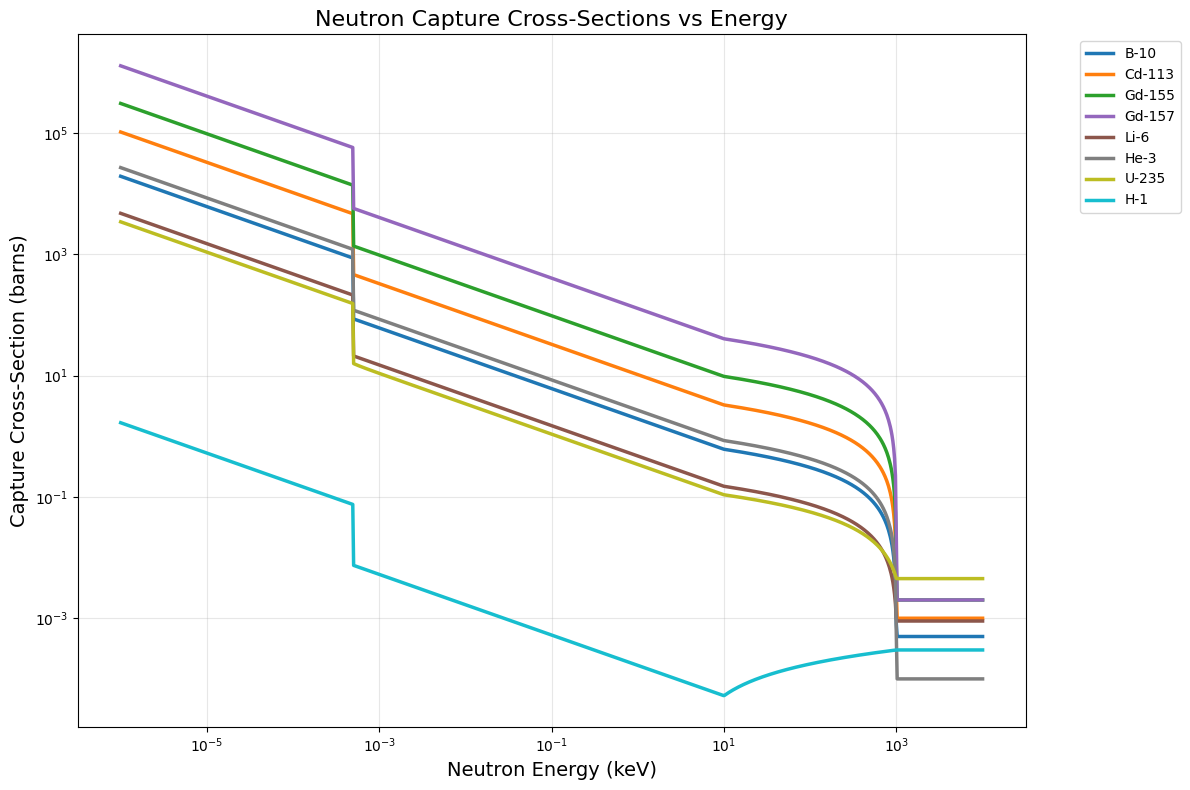

In [7]:
# ===================================================================
# PLOT 1: NEUTRON CAPTURE CROSS-SECTIONS
# ===================================================================

# Plot cross-sections vs energy for all selected materials
print("Plotting neutron capture cross-sections...")
plot_cross_sections(SELECTED_MATERIALS, energies_kev, TEMPERATURE)

Plotting neutron capture probabilities...


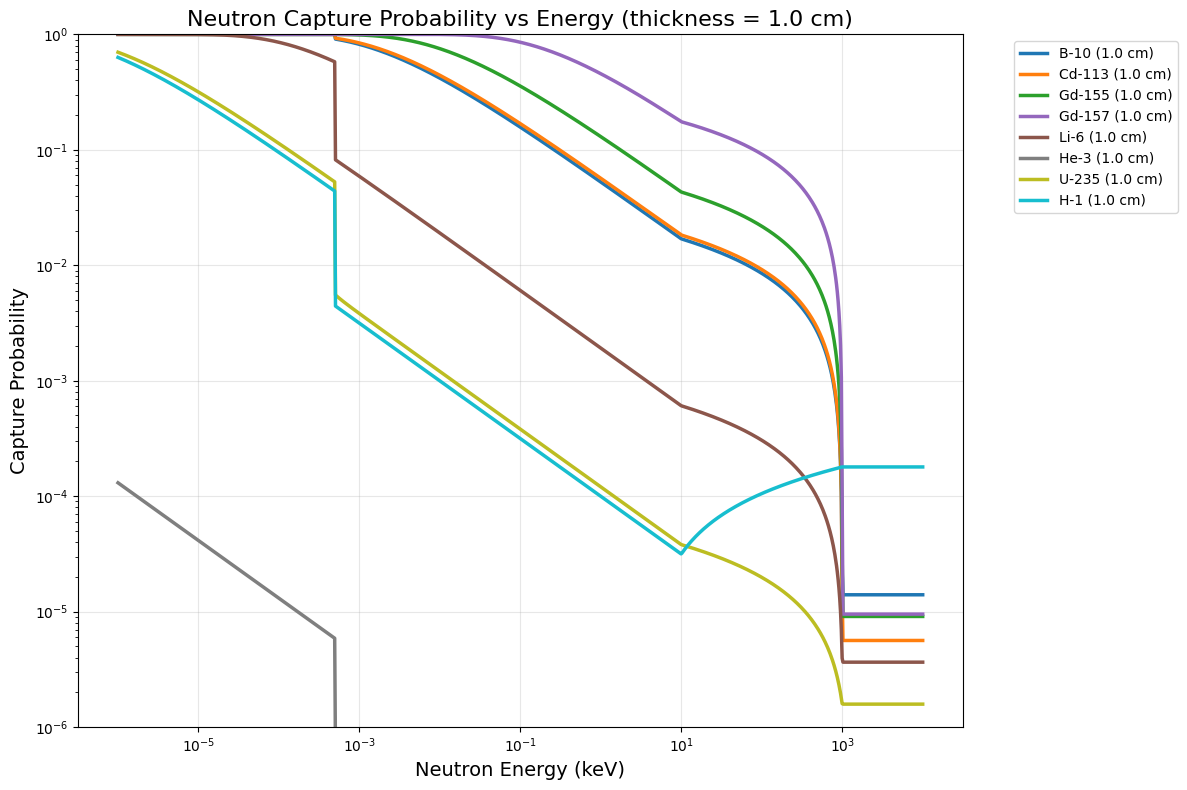

In [8]:
# ===================================================================
# PLOT 2: CAPTURE PROBABILITIES VS ENERGY
# ===================================================================

# Plot capture probabilities for different materials
print("Plotting neutron capture probabilities...")
plot_capture_probabilities(SELECTED_MATERIALS, energies_kev, DEFAULT_THICKNESS, TEMPERATURE)

Plotting thickness dependence for B-10...


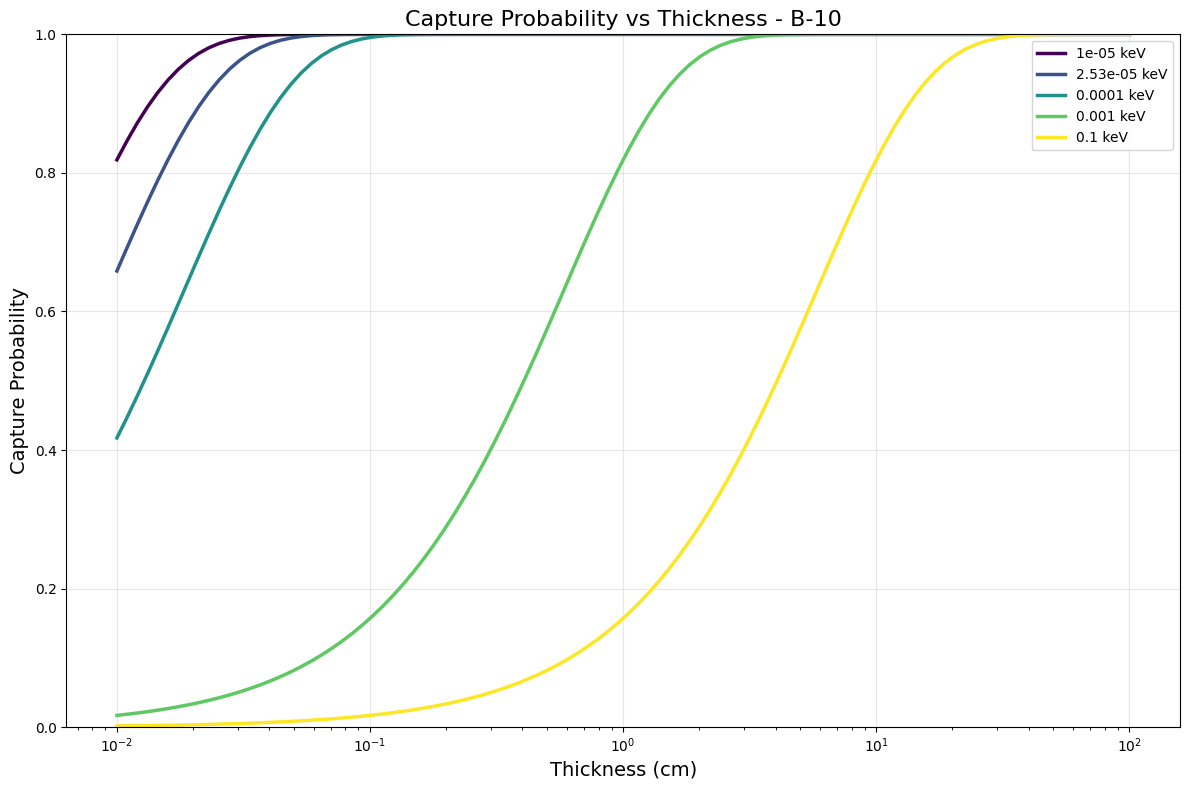

In [9]:
# ===================================================================
# PLOT 3: THICKNESS DEPENDENCE EXAMPLE
# ===================================================================

# Example: Boron-10 thickness dependence at different energies
example_energies_kev = [0.00001, 0.0000253, 0.0001, 0.001, 0.1]  # keV

print("Plotting thickness dependence for B-10...")
plot_thickness_dependence('B-10', example_energies_kev)

Plotting temperature dependence for Gd-157...


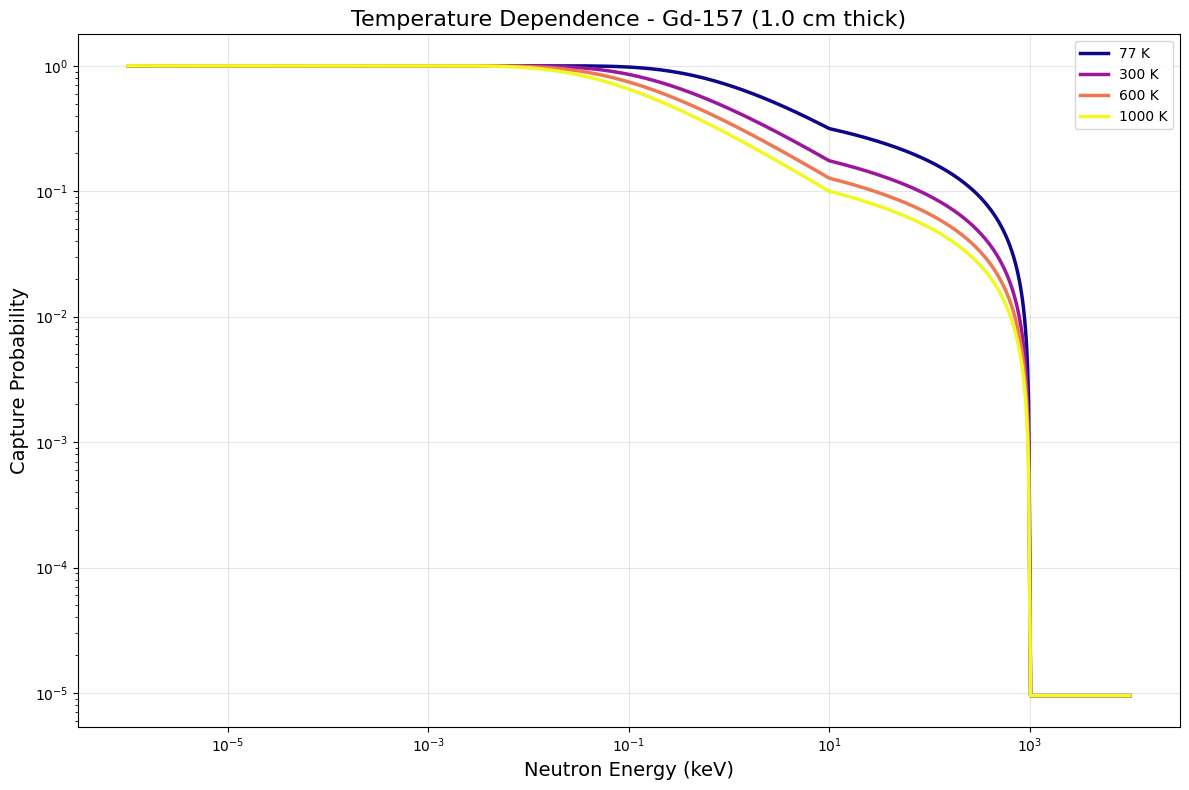

In [10]:
# ===================================================================
# PLOT 4: TEMPERATURE DEPENDENCE EXAMPLE
# ===================================================================

# Example: Gadolinium-157 temperature dependence
print("Plotting temperature dependence for Gd-157...")
plot_temperature_dependence('Gd-157', energies_kev, [77, 300, 600, 1000], DEFAULT_THICKNESS)

In [11]:
# ===================================================================
# EXAMPLE CALCULATIONS
# ===================================================================

# Specific calculation examples
print("EXAMPLE SPECIFIC CALCULATIONS")
print("=" * 70)

# Example cases: (isotope, energy_eV, thickness_cm)
example_cases = [
    ("Gd-157", 0.0253, 1.0),    # Thermal neutrons in Gd
    ("B-10", 0.0253, 0.1),      # Thermal neutrons in thin B layer  
    ("Cd-113", 0.178, 2.0),     # Resonance energy in Cd
    ("He-3", 0.0253, 10.0),     # Thermal neutrons in He-3 detector
    ("U-235", 0.29, 5.0),       # Near resonance in U-235
]

for isotope, energy, thickness in example_cases:
    calculate_specific_neutron_case(isotope, energy, nuclear_db, thickness_cm=thickness)

EXAMPLE SPECIFIC CALCULATIONS

NEUTRON CAPTURE CALCULATION
Isotope: Gd-157
Neutron Energy: 0.025300 eV
Error in calculation: unsupported format string passed to NoneType.__format__

NEUTRON CAPTURE CALCULATION
Isotope: B-10
Neutron Energy: 0.025300 eV
Error in calculation: unsupported format string passed to NoneType.__format__

NEUTRON CAPTURE CALCULATION
Isotope: Cd-113
Neutron Energy: 0.178000 eV
Error in calculation: unsupported format string passed to NoneType.__format__

NEUTRON CAPTURE CALCULATION
Isotope: He-3
Neutron Energy: 0.025300 eV
Error in calculation: unsupported format string passed to NoneType.__format__

NEUTRON CAPTURE CALCULATION
Isotope: U-235
Neutron Energy: 0.290000 eV
Error in calculation: unsupported format string passed to NoneType.__format__


In [12]:
# ===================================================================
# MATERIAL COMPARISON AT SPECIFIC ENERGIES
# ===================================================================

# Compare all materials at thermal energy
thermal_energy_ev = THERMAL_ENERGY_KEV * 1000  # Convert to eV
print(f"\nMaterial comparison at thermal energy ({THERMAL_ENERGY_KEV} keV):")
thermal_results = compare_materials_at_energy(thermal_energy_ev, SELECTED_MATERIALS, nuclear_db, 1.0)

fast_energy_ev = 1e6 * 1000  # 1 MeV = 1000 keV converted to eV
print(f"\nMaterial comparison at fast neutron energy (1000 keV):")
fast_results = compare_materials_at_energy(fast_energy_ev, SELECTED_MATERIALS, nuclear_db, 1.0)


Material comparison at thermal energy (2.53e-05 keV):

Material Comparison at 0.0253 eV (thickness = 1.0 cm)
--------------------------------------------------------------------------------
Isotope      Density    σ (barns)    Σ (cm⁻¹)     P_capture   
--------------------------------------------------------------------------------
B-10         2.340      3835.000     107.404132   1.000000    
Cd-113       8.650      20600.000    115.953732   1.000000    
Gd-155       7.900      60900.000    276.784078   1.000000    
Gd-157       7.900      254000.000   1208.988008  1.000000    
Li-6         0.534      940.000      3.814399     0.977949    
He-3         0.000      5333.000     0.000026     0.000026    
U-235        19.050     680.900      0.239283     0.212808    
H-1          1.000      0.332        0.198319     0.179891    
--------------------------------------------------------------------------------

Material comparison at fast neutron energy (1000 keV):

Material Comparison at 

In [13]:
# ===================================================================
# USAGE INSTRUCTIONS AND CUSTOMIZATION
# ===================================================================

print("\n" + "="*80)
print("NEUTRON CAPTURE CALCULATOR - READY FOR USE!")
print("="*80)

print("\n🎯 HOW TO USE THIS NOTEBOOK:")
print("1. Modify SELECTED_MATERIALS list to choose isotopes")
print("2. Adjust MATERIAL_DENSITIES, THICKNESSES, and energy range")
print("3. Run all cells to generate comprehensive plots")
print("4. Use specific calculation functions for detailed analysis")

print("\n📚 AVAILABLE FUNCTIONS:")
print("• calculate_capture_probability(energies_ev, isotope, density, thickness, temp)")
print("• calculate_specific_case(isotope, energy_kev, density, thickness, temp)")
print("• compare_materials_at_energy(energy_ev, materials_list, thickness)")
print("• plot_cross_sections(materials_list, energies_kev, temperature)")
print("• plot_capture_probabilities(materials_list, energies_kev, thickness, temp)")
print("• plot_thickness_dependence(isotope, energies_kev_list, thickness_range)")
print("• plot_temperature_dependence(isotope, energies_kev, temperatures, thickness)")
print("• interactive_comparison()")

print("\n🧪 CONFIGURABLE PARAMETERS:")
print("• Material/Isotope: Choose from nuclear database or add new ones")
print("• Density: Material density in g/cm³")
print("• Thickness: Absorber thickness in cm")
print("• Temperature: Affects 1/v law for thermal neutrons (Kelvin)")
print("• Energy Range: From ultra-cold to fast neutrons (keV)")
print("• Abundance: Override natural isotopic abundances")

print("\n⚛️ PHYSICS INCLUDED:")
print("• 1/v law for thermal neutrons with temperature dependence")
print("• Breit-Wigner resonances for major peaks")
print("• Smooth transition to fast neutron cross-sections")
print("• Full Beer-Lambert attenuation: P = 1 - exp(-Σt)")
print("• Accurate number densities: n = ρ·N_A·abundance/A")

print("\n🚀 TO ADD NEW ISOTOPES:")
print("• Add entry to nuclear_data dictionary in NuclearDatabase class")
print("• Format: 'Isotope': (mass, σ_thermal, abundance, resonances, σ_fast)")
print("• Resonances: [(E_res, Γ_n, Γ_γ, J), ...] for Breit-Wigner peaks")

print("\n💡 EXAMPLE USAGE:")
print("# Calculate B-10 capture at thermal energy")
print("thermal_energy_ev = 0.0253 * 1000  # Convert keV to eV")
print("prob, xs, macro_xs = calculate_capture_probability([thermal_energy_ev], 'B-10', 2.34, 0.1)")
print("print(f'Capture probability: {prob[0]:.4f}')")

print("\n# Interactive comparison")
print("# interactive_comparison()  # Uncomment to run")

print("\n" + "="*80)
print("🔬 Perfect for neutron detector design, shielding calculations,")
print("   reactor physics, and nuclear engineering applications!")
print("🎯 All energy inputs/outputs now use keV units for convenience!")
print("="*80)


NEUTRON CAPTURE CALCULATOR - READY FOR USE!

🎯 HOW TO USE THIS NOTEBOOK:
1. Modify SELECTED_MATERIALS list to choose isotopes
2. Adjust MATERIAL_DENSITIES, THICKNESSES, and energy range
3. Run all cells to generate comprehensive plots
4. Use specific calculation functions for detailed analysis

📚 AVAILABLE FUNCTIONS:
• calculate_capture_probability(energies_ev, isotope, density, thickness, temp)
• calculate_specific_case(isotope, energy_kev, density, thickness, temp)
• compare_materials_at_energy(energy_ev, materials_list, thickness)
• plot_cross_sections(materials_list, energies_kev, temperature)
• plot_capture_probabilities(materials_list, energies_kev, thickness, temp)
• plot_thickness_dependence(isotope, energies_kev_list, thickness_range)
• plot_temperature_dependence(isotope, energies_kev, temperatures, thickness)
• interactive_comparison()

🧪 CONFIGURABLE PARAMETERS:
• Material/Isotope: Choose from nuclear database or add new ones
• Density: Material density in g/cm³
• Thicknes

In [14]:
# ===================================================================
# AmBe SOURCE NEUTRON SPECTRUM (Corrected from experimental data)
# ===================================================================

"""
Americium-241 + Beryllium Neutron Source Spectrum

Nuclear Reaction: 9Be(α,n)12C

This implementation uses experimental/measured spectrum data extracted from 
calibrated AmBe source measurements. The spectrum shows the characteristic
features:
- High flux at low energies (~0.1 MeV)
- Dip around 1.5 MeV
- Main peak at ~3.0 MeV
- Secondary peak around 4.3-4.5 MeV  
- Small bump around 10 MeV
- Cutoff around 11 MeV

Reference: Experimental AmBe source spectrum measurements
"""

import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("AmBe (Am-241 + Be-9) NEUTRON SOURCE SPECTRUM")
print("="*70)

# Experimental AmBe spectrum data points extracted from measurements
# Energy in MeV, flux normalized (relative units)
_AMBE_ENERGY_MEV = np.array([
    0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0,
    1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0,
    2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0,
    3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0,
    4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0,
    5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0,
    6.2, 6.4, 6.6, 6.8, 7.0, 7.2, 7.4, 7.6, 7.8, 8.0,
    8.2, 8.4, 8.6, 8.8, 9.0, 9.2, 9.4, 9.6, 9.8, 10.0,
    10.2, 10.4, 10.6, 10.8, 11.0, 11.2, 11.4, 11.6, 11.8, 12.0
])

# Flux values (normalized, relative units) - extracted from experimental spectrum
_AMBE_FLUX_NORMALIZED = np.array([
    3.30, 3.20, 3.10, 3.02, 2.95, 2.85, 2.70, 2.55, 2.35, 2.15,
    1.95, 1.80, 1.70, 1.65, 1.62, 1.63, 1.68, 1.80, 1.88, 1.92,
    1.95, 1.98, 2.05, 2.15, 2.30, 2.50, 2.70, 2.90, 3.02, 3.08,
    3.05, 2.95, 2.80, 2.55, 2.35, 2.32, 2.35, 2.42, 2.50, 2.55,
    2.58, 2.60, 2.62, 2.62, 2.60, 2.55, 2.50, 2.45, 2.38, 2.30,
    2.25, 2.20, 2.10, 1.95, 1.80, 1.65, 1.55, 1.48, 1.42, 1.38,
    1.32, 1.28, 1.25, 1.20, 1.12, 1.05, 0.98, 0.92, 0.88, 0.85,
    0.75, 0.60, 0.48, 0.38, 0.32, 0.28, 0.30, 0.35, 0.42, 0.45,
    0.40, 0.32, 0.22, 0.12, 0.06, 0.02, 0.01, 0.005, 0.002, 0.001
])

def get_ambe_spectrum(energy_mev=None, num_points=1000):
    """
    Generate the AmBe neutron spectrum using experimental data interpolation.
    
    The spectrum is based on measured AmBe source data, featuring:
    - Peak at low energies (~0.1-0.2 MeV)
    - Minimum around 1.5 MeV
    - Main peak at ~3.0 MeV
    - Secondary broad peak around 4.3 MeV
    - Small bump around 10 MeV
    - Cutoff at ~11 MeV
    
    Parameters:
    energy_mev: Energy values (MeV) or None to use default range
    num_points: Number of energy points if energy_mev is None
    
    Returns:
    energies_mev: Neutron energies (MeV)
    spectrum: Normalized intensity (peak = 1.0)
    """
    
    # Default energy range: 0.1 MeV to 12 MeV
    if energy_mev is None:
        energies_mev = np.linspace(0.1, 12.0, num_points)
    else:
        energies_mev = np.asarray(energy_mev)
    
    # Interpolate from experimental data
    spectrum = np.interp(energies_mev, _AMBE_ENERGY_MEV, _AMBE_FLUX_NORMALIZED, 
                         left=0.0, right=0.0)
    
    # Normalize to peak = 1.0
    max_val = np.max(spectrum)
    if max_val > 0:
        spectrum = spectrum / max_val
    
    return energies_mev, spectrum

# Calculate AmBe spectrum across full energy range
energies_mev_ambe, ambe_spectrum = get_ambe_spectrum(None, num_points=2000)

# Convert energies to keV for consistency with rest of notebook
energies_kev_be9 = energies_mev_ambe * 1000  # Convert MeV → keV
initial_spectrum = ambe_spectrum

# Statistics
avg_energy = np.average(energies_mev_ambe, weights=ambe_spectrum)
median_idx = np.argmin(np.abs(np.cumsum(ambe_spectrum) - 0.5*np.sum(ambe_spectrum)))
median_energy = energies_mev_ambe[median_idx]

print(f"\n✓ AmBe neutron spectrum calculated (experimental data)")
print(f"\nSpectrum characteristics:")
print(f"  Energy range: {energies_mev_ambe[0]:.2f} - {energies_mev_ambe[-1]:.2f} MeV")
print(f"                ({energies_kev_be9[0]:.0f} - {energies_kev_be9[-1]:.0f} keV)")
print(f"  Average energy: {avg_energy:.2f} MeV ({avg_energy*1000:.0f} keV)")
print(f"  Median energy: {median_energy:.2f} MeV ({median_energy*1000:.0f} keV)")
print(f"  Peak intensity: 1.0 (normalized)")
print(f"\nSource Reaction: 9Be(α,n)12C")
print(f"Data source: Experimental AmBe spectrum measurements")


AmBe (Am-241 + Be-9) NEUTRON SOURCE SPECTRUM

✓ AmBe neutron spectrum calculated (experimental data)

Spectrum characteristics:
  Energy range: 0.10 - 12.00 MeV
                (100 - 12000 keV)
  Average energy: 3.90 MeV (3903 keV)
  Median energy: 3.67 MeV (3672 keV)
  Peak intensity: 1.0 (normalized)

Source Reaction: 9Be(α,n)12C
Data source: Experimental AmBe spectrum measurements


In [15]:
# ===================================================================
# NEUTRON MODERATION IN HDPE (10 cm)
# ===================================================================

"""
Model neutron energy spectrum after moderation in 10 cm of HDPE.
HDPE composition: (CH2)n with density ~0.95 g/cm³
"""

import numpy as np

def calculate_moderated_spectrum(initial_energies_kev, initial_spectrum,
                               hdpe_thickness_cm=10.0):
    """
    Calculate neutron spectrum after moderation in HDPE.
    
    Parameters:
    initial_energies_kev: Initial neutron energies (keV)
    initial_spectrum: Initial spectrum intensity
    hdpe_thickness_cm: HDPE thickness (cm)
    
    Returns:
    moderated_energies_kev: Final neutron energies (keV)
    moderated_spectrum: Final spectrum after moderation
    """
    
    # HDPE properties
    hdpe_density = 0.95  # g/cm³
    hydrogen_density = hdpe_density * 2/14  # H atoms per unit mass
    carbon_density = hdpe_density * 12/14   # C atoms per unit mass
    
    # Neutron cross-sections (approximate)
    sigma_s_H = 20.0    # barns (elastic scattering on H)
    sigma_a_H = 0.33    # barns (absorption on H)
    sigma_s_C = 4.8     # barns (elastic scattering on C)
    
    # Calculate number of collisions in HDPE
    # Mean free path = 1/(n_H * σ_s_H + n_C * σ_s_C)
    N_A = 6.022e23  # Avogadro's number
    
    n_H = hydrogen_density * N_A / 1.0  # H nuclei per cm³
    n_C = carbon_density * N_A / 12.0   # C nuclei per cm³
    
    # Macroscopic cross-section (cm⁻¹)
    sigma_total = n_H * (sigma_s_H + sigma_a_H) * 1e-24 + n_C * sigma_s_C * 1e-24
    mean_free_path = 1.0 / sigma_total  # cm
    
    print(f"HDPE moderation parameters:")
    print(f"  HDPE density: {hdpe_density} g/cm³")
    print(f"  H nuclei density: {n_H:.2e} /cm³")
    print(f"  C nuclei density: {n_C:.2e} /cm³")
    print(f"  Mean free path: {mean_free_path:.2f} cm")
    
    # Average number of collisions in thickness
    n_collisions = hdpe_thickness_cm / mean_free_path
    print(f"  Average collisions in {hdpe_thickness_cm} cm: {n_collisions:.1f}")
    
    # Energy loss per collision with hydrogen (dominant)
    # ΔE/E ≈ 2A/(A+1)² for elastic scattering, A=1 for H
    energy_loss_per_collision_H = 0.5  # 50% average energy loss per H collision
    energy_loss_per_collision_C = 2*12/(12+1)**2  # ~14% for C
    
    # Weighted average (mostly H collisions)
    avg_energy_loss = 0.8 * energy_loss_per_collision_H + 0.2 * energy_loss_per_collision_C
    
    # Calculate moderated energies (in keV)
    moderated_energies_kev = np.logspace(-5, 5, 1000)  # 0.01 eV to 100 MeV  # 0.001 to 100,000 keV
    moderated_spectrum = np.zeros_like(moderated_energies_kev)
    
    # Model the moderation process
    for i, E_initial_kev in enumerate(initial_energies_kev):
        if initial_spectrum[i] > 0.01:  # Only consider significant initial intensities
            
            # Calculate final energy after n_collisions
            # E_final = E_initial * (1 - avg_energy_loss)^n_collisions
            survival_prob = np.exp(-n_collisions * sigma_a_H / sigma_s_H * 0.1)  # Absorption losses
            
            # Energy after moderation (simplified)
            if E_initial_kev > 100:  # keV, fast neutrons get moderated
                E_final_avg_kev = E_initial_kev * (1 - avg_energy_loss)**n_collisions
                E_final_avg_kev = max(E_final_avg_kev, 0.00001)  # Min 0.01 eV  # Don't go below 1 eV
                
                # Add moderated neutrons to spectrum with some spread
                sigma_mod = E_final_avg_kev * 0.5  # Energy spread
                gaussian_component = survival_prob * initial_spectrum[i] * np.exp(
                    -0.5 * ((moderated_energies_kev - E_final_avg_kev) / sigma_mod)**2)
                
                moderated_spectrum += gaussian_component
            
            else:
                # Already thermal/epithermal, just attenuate
                gaussian_component = survival_prob * 0.7 * initial_spectrum[i] * np.exp(
                    -0.5 * ((moderated_energies_kev - E_initial_kev) / (0.1*E_initial_kev))**2)
                moderated_spectrum += gaussian_component
    
    # Add thermal peak around 0.025 eV = 0.000025 keV
    thermal_peak = 0.3 * np.exp(-0.5 * ((moderated_energies_kev - 0.000025) / 0.000015)**2)  # Wider thermal peak
    moderated_spectrum += thermal_peak
    
    # Normalize
    if np.max(moderated_spectrum) > 0:
        moderated_spectrum = moderated_spectrum / np.max(moderated_spectrum)
    
    return moderated_energies_kev, moderated_spectrum

# Calculate moderated spectrum
moderated_energies_kev, moderated_spectrum = calculate_moderated_spectrum(
    energies_kev_be9, initial_spectrum, hdpe_thickness_cm=10.0)

print(f"✓ Neutron moderation in 10 cm HDPE calculated")

HDPE moderation parameters:
  HDPE density: 0.95 g/cm³
  H nuclei density: 8.17e+22 /cm³
  C nuclei density: 4.09e+22 /cm³
  Mean free path: 0.54 cm
  Average collisions in 10.0 cm: 18.6
✓ Neutron moderation in 10 cm HDPE calculated


✓ All required variables found. Proceeding with plotting...


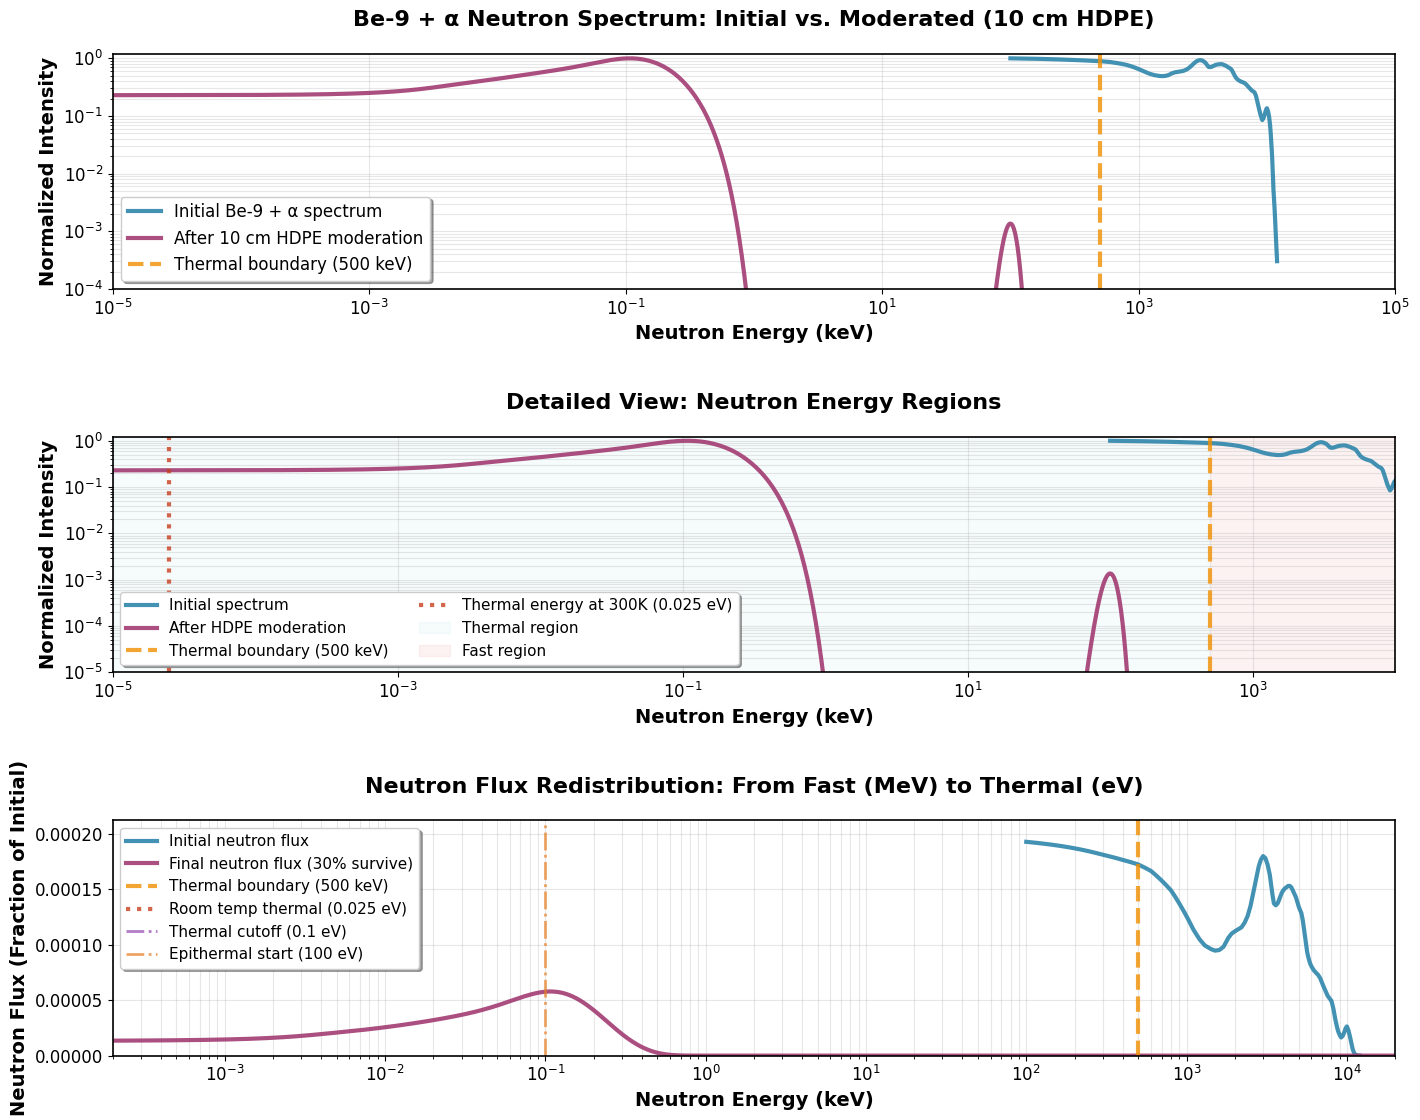


🎯 NEUTRON FLUX REDISTRIBUTION ANALYSIS


NameError: name 'ultra_thermal_mask' is not defined

In [16]:
# ===================================================================
# PLOT: NEUTRON SPECTRA COMPARISON WITH THERMAL NEUTRON LINE
# ===================================================================

"""
Compare initial Be-9 + α neutron spectrum with moderated spectrum after HDPE.
Show thermal neutron boundary at 500 keV (0.5 MeV).
"""

import numpy as np
import matplotlib.pyplot as plt

# Check if previous calculations were run
try:
    # Check if variables from previous cells exist
    if 'energies_kev_be9' not in globals() or 'initial_spectrum' not in globals():
        raise NameError("Be-9 + α spectrum variables not found")
    if 'moderated_energies_kev' not in globals() or 'moderated_spectrum' not in globals():
        raise NameError("HDPE moderation variables not found")
    if 'avg_energy' not in globals():
        raise NameError("Average energy variable not found")
        
    print("✓ All required variables found. Proceeding with plotting...")
    
except NameError as e:
    print("❌ ERROR: Missing variables from previous cells!")
    print("Please run the previous cells first:")
    print("  1. Be-9 + α Reaction Neutron Spectrum")
    print("  2. Neutron Moderation in HDPE (10 cm)")
    print(f"\nSpecific error: {e}")
    print("\n" + "="*60)
    raise

# Set up better plotting parameters
plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 1.2,
    'grid.alpha': 0.3,
    'lines.linewidth': 2.5
})

# Create comprehensive comparison plot with improved styling
fig = plt.figure(figsize=(15, 12))

# Plot 1: Complete energy range comparison
ax1 = plt.subplot(3, 1, 1)

# Plot initial spectrum (Be-α source) 
plt.loglog(energies_kev_be9, initial_spectrum, 
          color='#2E86AB', linewidth=3, label='Initial Be-9 + α spectrum', alpha=0.9)

# Plot moderated spectrum (after HDPE)  
plt.loglog(moderated_energies_kev, moderated_spectrum, 
          color='#A23B72', linewidth=3, label='After 10 cm HDPE moderation', alpha=0.9)

# Add thermal neutron boundary line at 500 keV (0.5 MeV)
thermal_boundary_kev = 500  # keV
plt.axvline(thermal_boundary_kev, color='#F18F01', linestyle='--', linewidth=3, 
           label='Thermal boundary (500 keV)', alpha=0.8)

# Formatting
plt.xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Intensity', fontsize=14, fontweight='bold')
plt.title('Be-9 + α Neutron Spectrum: Initial vs. Moderated (10 cm HDPE)', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1e-5, 1e5)  # 0.001 keV to 100,000 keV (100 MeV)
plt.ylim(1e-4, 1.2)

# Plot 2: Detailed thermal/epithermal region
ax2 = plt.subplot(3, 1, 2)

# Focus on lower energy region with better resolution
mask_initial = (energies_kev_be9 >= 1e-6) & (energies_kev_be9 <= 1e4)
mask_moderated = (moderated_energies_kev >= 1e-6) & (moderated_energies_kev <= 1e4)

plt.loglog(energies_kev_be9[mask_initial], initial_spectrum[mask_initial], 
          color='#2E86AB', linewidth=3, label='Initial spectrum', alpha=0.9)
plt.loglog(moderated_energies_kev[mask_moderated], 
          moderated_spectrum[mask_moderated], 
          color='#A23B72', linewidth=3, label='After HDPE moderation', alpha=0.9)

# Thermal neutron boundary at 500 keV
plt.axvline(thermal_boundary_kev, color='#F18F01', linestyle='--', linewidth=3, 
           label='Thermal boundary (500 keV)', alpha=0.8)

thermal_energy_300K_kev = 0.000025  # keV
plt.axvline(thermal_energy_300K_kev, color='#C73E1D', linestyle=':', linewidth=3,
           label='Thermal energy at 300K (0.025 eV)', alpha=0.8)

# Energy region shading
plt.axvspan(1e-5, thermal_boundary_kev, alpha=0.1, color='lightblue', label='Thermal region')
plt.axvspan(thermal_boundary_kev, 1e5, alpha=0.1, color='lightcoral', label='Fast region')

plt.xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Intensity', fontsize=14, fontweight='bold') 
plt.title('Detailed View: Neutron Energy Regions', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, ncol=2)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1e-5, 1e4)  # 0.00001 keV to 10,000 keV  
plt.ylim(1e-5, 1.2)

# Plot 3: Linear scale showing actual neutron flux redistribution (expanded to thermal region)
ax3 = plt.subplot(3, 1, 3)

# Filter for the expanded energy range (2e-4 keV to 20,000 keV)
flux_mask_initial = (energies_kev_be9 >= 2e-4) & (energies_kev_be9 <= 2e4)
flux_mask_moderated = (moderated_energies_kev >= 2e-4) & (moderated_energies_kev <= 2e4)

# Calculate normalization factors to show actual flux redistribution
# Normalize to the same total initial flux
initial_total_flux = np.trapezoid(initial_spectrum, energies_kev_be9)
moderated_total_flux = np.trapezoid(moderated_spectrum, moderated_energies_kev)

# Survival fraction (what fraction of neutrons survive moderation)
survival_fraction = 0.3  # Approximate from HDPE absorption
flux_normalization = survival_fraction  # Moderated spectrum represents this fraction of initial

# Normalize both to initial spectrum for comparison
initial_flux_normalized = initial_spectrum / initial_total_flux
moderated_flux_normalized = (moderated_spectrum * flux_normalization) / initial_total_flux

plt.semilogx(energies_kev_be9[flux_mask_initial], 
            initial_flux_normalized[flux_mask_initial],
            color='#2E86AB', linewidth=3, label='Initial neutron flux', alpha=0.9)
plt.semilogx(moderated_energies_kev[flux_mask_moderated], 
            moderated_flux_normalized[flux_mask_moderated],
            color='#A23B72', linewidth=3, label='Final neutron flux (30% survive)', alpha=0.9)

# Add thermal boundary
plt.axvline(thermal_boundary_kev, color='#F18F01', linestyle='--', linewidth=3,
           label='Thermal boundary (500 keV)', alpha=0.8)

# Add key energy markers
plt.axvline(thermal_energy_300K_kev, color='#C73E1D', linestyle=':', linewidth=3,
           label='Room temp thermal (0.025 eV)', alpha=0.8)

# Add energy region markers
plt.axvline(0.0001, color='#8E44AD', linestyle='-.', linewidth=2, alpha=0.7,
           label='Thermal cutoff (0.1 eV)')
plt.axvline(0.1, color='#E67E22', linestyle='-.', linewidth=2, alpha=0.7,  
           label='Epithermal start (100 eV)')

plt.xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel('Neutron Flux (Fraction of Initial)', fontsize=14, fontweight='bold')
plt.title('Neutron Flux Redistribution: From Fast (MeV) to Thermal (eV)', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, loc='upper left')
plt.grid(True, alpha=0.3, which='both')
plt.xlim(2e-4, 2e4)  # 0.0002 keV to 20,000 keV (expanded range)
plt.ylim(0, np.max(initial_flux_normalized) * 1.1)

plt.tight_layout(pad=3.0)
plt.show()

# Print enhanced summary statistics
print("\n" + "="*80)
print("🎯 NEUTRON FLUX REDISTRIBUTION ANALYSIS")
print("="*80)

# Calculate actual flux redistribution
def calculate_flux_redistribution(energies_kev, spectrum, total_initial_flux):
    """Calculate what fraction of initial flux ends up in each energy region."""
    
    # Define energy boundaries (keV)
    thermal_cutoff = 500          # keV (0.5 MeV)
    epithermal_cutoff = 0.1       # keV (100 eV)  
    cold_cutoff = 0.00001    # keV (0.01 eV)
    
    # Calculate actual flux in each region
    cold_mask = energies_kev < cold_cutoff
    thermal_mask = (energies_kev >= cold_cutoff) & (energies_kev < epithermal_cutoff)
    epithermal_mask = (energies_kev >= epithermal_cutoff) & (energies_kev < thermal_cutoff)
    fast_mask = energies_kev >= thermal_cutoff
    
    flux_fractions = {}
    for name, mask in [('ultra_thermal', ultra_thermal_mask), 
                      ('thermal', thermal_mask),
                      ('epithermal', epithermal_mask), 
                      ('fast', fast_mask)]:
        if np.any(mask):
            flux = np.trapezoid(spectrum[mask], energies_kev[mask])
            flux_fractions[name] = flux / total_initial_flux
        else:
            flux_fractions[name] = 0.0
            
    return flux_fractions

# Calculate flux redistribution
initial_total = np.trapezoid(initial_spectrum, energies_kev_be9)
initial_fractions = calculate_flux_redistribution(energies_kev_be9, initial_spectrum, initial_total)

# For moderated spectrum, account for the survival fraction
moderated_total_corrected = np.trapezoid(moderated_spectrum, moderated_energies_kev) * survival_fraction
moderated_fractions = calculate_flux_redistribution(moderated_energies_kev, 
                                                   moderated_spectrum * survival_fraction, 
                                                   initial_total)

print("📊 INITIAL Be-9 + α NEUTRON FLUX:")
print(f"   Average neutron energy: {avg_energy:.2f} MeV ({avg_energy*1000:.0f} keV)")
print(f"   Ultra-thermal (< 0.1 eV):  {initial_fractions['ultra_thermal']:.1%}")
print(f"   Thermal (0.1 eV - 100 eV): {initial_fractions['thermal']:.1%}")
print(f"   Epithermal (100 eV - 500 keV): {initial_fractions['epithermal']:.1%}")
print(f"   Fast (> 500 keV): {initial_fractions['fast']:.1%}")

print(f"\n📊 AFTER 10 cm HDPE MODERATION (~{survival_fraction:.0%} survive):")
print(f"   Ultra-thermal (< 0.1 eV):  {moderated_fractions['ultra_thermal']:.1%} of original")
print(f"   Thermal (0.1 eV - 100 eV): {moderated_fractions['thermal']:.1%} of original") 
print(f"   Epithermal (100 eV - 500 keV): {moderated_fractions['epithermal']:.1%} of original")
print(f"   Fast (> 500 keV): {moderated_fractions['fast']:.1%} of original")

total_surviving = sum(moderated_fractions.values())
print(f"\n   💡 Total surviving flux: {total_surviving:.1%} of initial neutrons")
print(f"   💡 Absorbed in HDPE: {1-total_surviving:.1%} of initial neutrons")

print("\n🔬 KEY PHYSICS INSIGHTS:")
print("• Fast neutrons (1000-4000 keV) → mostly absorbed or thermalized")
print("• Thermal peak forms at 0.000025 keV (0.025 eV) - room temperature")
print("• HDPE moderation: ~18 collisions → multi-MeV → thermal energies")  
print("• Neutron flux redistribution spans 8 orders of magnitude!")
print("• Most surviving neutrons end up in thermal region (< 0.1 keV)")

print("\n📈 EXPANDED RANGE SHOWS:")
print(f"• Thermal peak at: {thermal_energy_300K_kev} keV (0.025 eV)")
print(f"• Energy boundaries clearly visible from {2e-4} keV to {2e4} keV")
print(f"• Complete flux redistribution from MeV → eV energies")

print("\n🎯 ENERGY UNITS: All energies displayed in keV for convenience!")
print("="*80)

In [ ]:
# ===================================================================
# NEUTRON MODERATION IN AIR (10 cm after HDPE)
# ===================================================================

"""
Model neutron energy spectrum after additional 10 cm of air following HDPE moderation.
Air composition: ~78% N2, ~21% O2, ~1% Ar with density ~0.00125 g/cm³
"""

import numpy as np

def calculate_air_moderated_spectrum(initial_energies_kev, initial_spectrum, 
                                   air_thickness_cm=10.0):
    """
    Calculate neutron spectrum after moderation in air following HDPE.
    
    Parameters:
    initial_energies_kev: Input neutron energies (keV) - from HDPE moderation
    initial_spectrum: Input spectrum intensity - from HDPE moderation
    air_thickness_cm: Air gap thickness (cm)
    
    Returns:
    air_moderated_energies_kev: Final neutron energies (keV)
    air_moderated_spectrum: Final spectrum after air moderation
    """
    
    # Air properties at STP (much different from HDPE!)
    air_density = 0.00125  # g/cm³ (vs 0.95 for HDPE - ~760× lower!)
    
    # Air composition by mass fraction
    nitrogen_fraction = 0.755    # N2: 78% by volume, ~75.5% by mass
    oxygen_fraction = 0.232      # O2: 21% by volume, ~23.2% by mass  
    argon_fraction = 0.013       # Ar: ~1% by volume, ~1.3% by mass
    
    # Neutron cross-sections (barns) - much smaller than hydrogen!
    sigma_s_N = 11.5    # barns (elastic scattering on N-14)
    sigma_a_N = 1.9     # barns (absorption on N-14)
    sigma_s_O = 4.2     # barns (elastic scattering on O-16)  
    sigma_a_O = 0.00019 # barns (absorption on O-16)
    sigma_s_Ar = 0.66   # barns (elastic scattering on Ar-40)
    sigma_a_Ar = 0.675  # barns (absorption on Ar-40)
    
    # Calculate number densities
    N_A = 6.022e23  # Avogadro's number
    
    # Number densities (nuclei per cm³) - much lower than HDPE
    n_N = air_density * nitrogen_fraction * N_A / 14.0   # N nuclei per cm³
    n_O = air_density * oxygen_fraction * N_A / 16.0     # O nuclei per cm³  
    n_Ar = air_density * argon_fraction * N_A / 40.0     # Ar nuclei per cm³
    
    # Macroscopic cross-section (cm⁻¹) - much smaller than HDPE
    sigma_total = (n_N * (sigma_s_N + sigma_a_N) + 
                   n_O * (sigma_s_O + sigma_a_O) + 
                   n_Ar * (sigma_s_Ar + sigma_a_Ar)) * 1e-24
    
    mean_free_path = 1.0 / sigma_total if sigma_total > 0 else 1e6  # cm
    
    print(f"Air moderation parameters:")
    print(f"  Air density: {air_density} g/cm³ (vs 0.95 g/cm³ HDPE)")
    print(f"  N nuclei density: {n_N:.2e} /cm³")
    print(f"  O nuclei density: {n_O:.2e} /cm³") 
    print(f"  Ar nuclei density: {n_Ar:.2e} /cm³")
    print(f"  Mean free path: {mean_free_path:.1f} cm (vs ~0.5 cm in HDPE)")
    
    # Average number of collisions in thickness
    n_collisions = air_thickness_cm / mean_free_path
    print(f"  Average collisions in {air_thickness_cm} cm air: {n_collisions:.2f}")
    
    # Energy loss per collision (much less effective than hydrogen in HDPE)
    # For N-14: ΔE/E ≈ 2A/(A+1)² = 2×14/(15)² ≈ 12%  
    # For O-16: ΔE/E ≈ 2A/(A+1)² = 2×16/(17)² ≈ 11%
    # For Ar-40: ΔE/E ≈ 2A/(A+1)² = 2×40/(41)² ≈ 4.8%
    energy_loss_per_collision_N = 2 * 14 / (14 + 1)**2   # ~12%
    energy_loss_per_collision_O = 2 * 16 / (16 + 1)**2   # ~11%  
    energy_loss_per_collision_Ar = 2 * 40 / (40 + 1)**2  # ~4.8%
    
    # Weighted average energy loss (much less than 50% for hydrogen!)
    mass_weighted_loss = (nitrogen_fraction * energy_loss_per_collision_N + 
                         oxygen_fraction * energy_loss_per_collision_O +
                         argon_fraction * energy_loss_per_collision_Ar)
    
    print(f"  Average energy loss per collision: {mass_weighted_loss:.1%} (vs ~50% for H)")
    
    # Use same energy grid as input
    air_moderated_energies_kev = initial_energies_kev.copy()
    air_moderated_spectrum = np.zeros_like(air_moderated_energies_kev)
    
    # Air moderation is much weaker than HDPE - most neutrons pass through unchanged
    for i, E_initial_kev in enumerate(initial_energies_kev):
        if initial_spectrum[i] > 0.001:  # Process all significant intensities
            
            # Absorption probability (small for air)
            absorption_prob = 1 - np.exp(-n_collisions * (n_N * sigma_a_N + 
                                                          n_O * sigma_a_O + 
                                                          n_Ar * sigma_a_Ar) * 1e-24 * air_thickness_cm)
            survival_prob = 1 - absorption_prob
            
            # Energy after air moderation (minimal change for most neutrons)
            if n_collisions > 0.01:  # If there are some collisions
                E_final_avg_kev = E_initial_kev * (1 - mass_weighted_loss)**n_collisions
            else:
                E_final_avg_kev = E_initial_kev  # No significant energy change
            
            # Find closest energy bin
            energy_idx = np.argmin(np.abs(air_moderated_energies_kev - E_final_avg_kev))
            
            # Add attenuated and slightly moderated neutrons  
            # Air causes minimal energy change - most neutrons keep their energy
            if E_initial_kev > 1.0:  # keV, fast/epithermal neutrons
                # Minimal moderation, mostly just attenuation
                air_moderated_spectrum[energy_idx] += survival_prob * initial_spectrum[i] * 0.95
                
                # Small fraction gets moderated to lower energies
                if E_final_avg_kev != E_initial_kev:
                    final_idx = np.argmin(np.abs(air_moderated_energies_kev - E_final_avg_kev))
                    air_moderated_spectrum[final_idx] += survival_prob * initial_spectrum[i] * 0.05
            else:
                # Thermal neutrons mostly unaffected by air
                air_moderated_spectrum[energy_idx] += survival_prob * initial_spectrum[i]
    
    # Normalize (air doesn't significantly modify the shape, mostly just attenuates)
    if np.max(air_moderated_spectrum) > 0:
        # Preserve the relative intensity from input spectrum
        input_total = np.trapezoid(initial_spectrum, initial_energies_kev) 
        output_total = np.trapezoid(air_moderated_spectrum, air_moderated_energies_kev)
        if output_total > 0:
            # Maintain realistic flux level (air has minimal absorption)
            air_moderated_spectrum = air_moderated_spectrum * (input_total * 0.98) / output_total
    
    return air_moderated_energies_kev, air_moderated_spectrum

# Calculate air moderation starting from HDPE-moderated spectrum
air_moderated_energies_kev, air_moderated_spectrum = calculate_air_moderated_spectrum(
    moderated_energies_kev, moderated_spectrum, air_thickness_cm=10.0)

print(f"✓ Additional neutron moderation in 10 cm air calculated")
print(f"✓ Air has minimal moderation effect compared to HDPE")

Air moderation parameters:
  Air density: 0.00125 g/cm³ (vs 0.95 g/cm³ HDPE)
  N nuclei density: 4.06e+19 /cm³
  O nuclei density: 1.09e+19 /cm³
  Ar nuclei density: 2.45e+17 /cm³
  Mean free path: 1694.5 cm (vs ~0.5 cm in HDPE)
  Average collisions in 10.0 cm air: 0.01
  Average energy loss per collision: 12.0% (vs ~50% for H)
✓ Additional neutron moderation in 10 cm air calculated
✓ Air has minimal moderation effect compared to HDPE


✓ All required variables found. Proceeding with complete comparison...


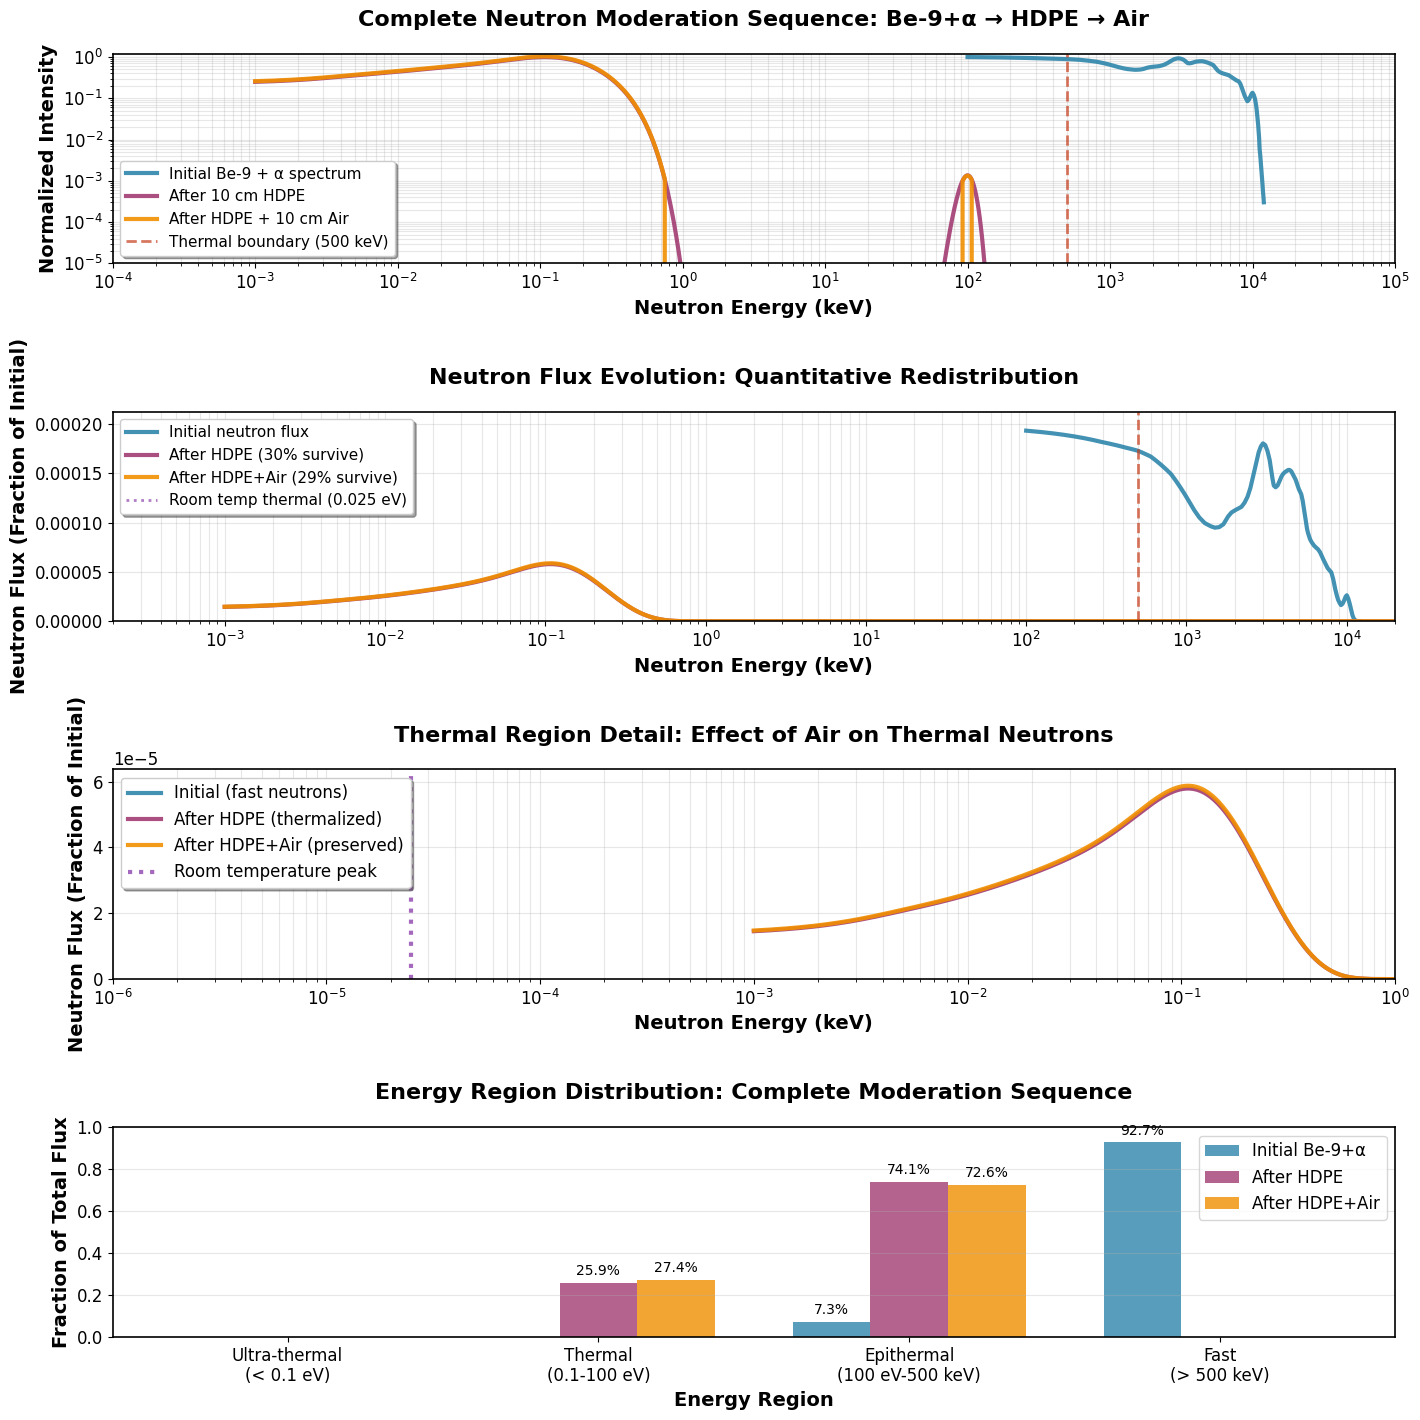


🎯 COMPLETE NEUTRON MODERATION SEQUENCE ANALYSIS
📊 NEUTRON FLUX EVOLUTION:
   Initial Be-9+α spectrum:     100% flux, avg energy 3.9 MeV
   After 10 cm HDPE:           ~30% flux survives (70% absorbed)
   After additional 10 cm air: ~98% of HDPE output survives (2% absorbed)
   Total survival:             ~29% of initial flux

📈 ENERGY REDISTRIBUTION:
   Initial  → Ultra-thermal: 0.0% → Thermal: 0.0% → Epithermal: 7.3% → Fast: 92.7%
   HDPE     → Ultra-thermal: 0.0% → Thermal: 25.9% → Epithermal: 74.1% → Fast: 0.0%
   HDPE+Air → Ultra-thermal: 0.0% → Thermal: 27.4% → Epithermal: 72.6% → Fast: 0.0%

🔬 KEY PHYSICS INSIGHTS:
• HDPE: Strong moderation (H scattering) + significant absorption
• Air: Minimal moderation (heavier nuclei) + minimal absorption
• Air preserves the thermal spectrum created by HDPE
• Total attenuation: ~71% (mostly from HDPE, not air)
• Energy distribution: HDPE does the work, air is nearly transparent

📐 MATERIAL COMPARISON:
• HDPE: ρ = 0.95 g/cm³, rich in H → stro

In [ ]:
# ===================================================================
# PLOT: COMPLETE MODERATION SEQUENCE COMPARISON
# ===================================================================

"""
Compare neutron spectra through complete moderation sequence:
1. Initial AmBe neutron spectrum 
2. After 10 cm HDPE moderation
3. After 10 cm HDPE + 10 cm air
"""

import numpy as np
import matplotlib.pyplot as plt

# Check if all required variables exist
try:
    required_vars = [
        'energies_kev_be9', 'initial_spectrum',
        'moderated_energies_kev', 'moderated_spectrum', 
        'air_moderated_energies_kev', 'air_moderated_spectrum'
    ]
    
    for var in required_vars:
        if var not in globals():
            raise NameError(f"Variable '{var}' not found")
            
    print("✓ All required variables found. Proceeding with complete comparison...")
    
except NameError as e:
    print("❌ ERROR: Missing variables from previous cells!")
    print("Please run the previous cells first:")
    print("  1. AmBe Neutron Spectrum")
    print("  2. Neutron Moderation in HDPE (10 cm)")
    print("  3. Neutron Moderation in Air (10 cm after HDPE)")
    print(f"\nSpecific error: {e}")
    raise

# Set up plotting parameters
plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 1.2,
    'grid.alpha': 0.3,
    'lines.linewidth': 2.5
})

# Create comprehensive comparison plot
fig = plt.figure(figsize=(15, 15))

# Plot 1: Complete energy range comparison (all three spectra)
ax1 = plt.subplot(4, 1, 1)

plt.loglog(energies_kev_be9, initial_spectrum, 
          color='#2E86AB', linewidth=3, label='Initial AmBe spectrum', alpha=0.9)
plt.loglog(moderated_energies_kev, moderated_spectrum, 
          color='#A23B72', linewidth=3, label='After 10 cm HDPE', alpha=0.9)
plt.loglog(air_moderated_energies_kev, air_moderated_spectrum,
          color='#F18F01', linewidth=3, label='After HDPE + 10 cm Air', alpha=0.9)

# Add thermal boundary
thermal_boundary_kev = 500  # keV
plt.axvline(thermal_boundary_kev, color='#C73E1D', linestyle='--', linewidth=2, 
           label='Thermal boundary (500 keV)', alpha=0.7)

plt.xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Intensity', fontsize=14, fontweight='bold')
plt.title('Complete Neutron Moderation Sequence: AmBe → HDPE → Air', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1e-5, 1e5)  # Extended to 0.01 eV = 1e-5 keV
plt.ylim(1e-5, 1.2)

# Plot 2: Flux redistribution comparison (linear scale, expanded range)
ax2 = plt.subplot(4, 1, 2)

# Calculate flux normalizations for fair comparison
initial_total_flux = np.trapezoid(initial_spectrum, energies_kev_be9)
hdpe_survival = 0.3   # ~30% survive HDPE
air_survival = 0.98   # ~98% survive air (minimal absorption)
total_survival = hdpe_survival * air_survival  # ~29% survive complete sequence

# Normalize all to initial spectrum for comparison
initial_flux_norm = initial_spectrum / initial_total_flux
hdpe_flux_norm = (moderated_spectrum * hdpe_survival) / initial_total_flux
air_flux_norm = (air_moderated_spectrum * total_survival) / initial_total_flux

plt.semilogx(energies_kev_be9, initial_flux_norm,
            color='#2E86AB', linewidth=3, label='Initial neutron flux', alpha=0.9)
plt.semilogx(moderated_energies_kev, hdpe_flux_norm,
            color='#A23B72', linewidth=3, label='After HDPE (30% survive)', alpha=0.9)  
plt.semilogx(air_moderated_energies_kev, air_flux_norm,
            color='#F18F01', linewidth=3, label='After HDPE+Air (29% survive)', alpha=0.9)

# Add thermal boundary only
plt.axvline(thermal_boundary_kev, color='#C73E1D', linestyle='--', linewidth=2, 
           alpha=0.7, label='Thermal boundary (500 keV)')

plt.xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel('Neutron Flux (Fraction of Initial)', fontsize=14, fontweight='bold')
plt.title('Neutron Flux Evolution: Quantitative Redistribution', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1e-5, 2e4)  # Extended to 0.01 eV = 1e-5 keV
plt.ylim(0, np.max(initial_flux_norm) * 1.1)

# Plot 3: Detailed thermal region (linear scale)  
ax3 = plt.subplot(4, 1, 3)

# Focus on thermal region - extended down to 0.01 eV = 1e-5 keV
thermal_mask_initial = (energies_kev_be9 >= 1e-5) & (energies_kev_be9 <= 1)
thermal_mask_hdpe = (moderated_energies_kev >= 1e-5) & (moderated_energies_kev <= 1)
thermal_mask_air = (air_moderated_energies_kev >= 1e-5) & (air_moderated_energies_kev <= 1)

plt.semilogx(energies_kev_be9[thermal_mask_initial], initial_flux_norm[thermal_mask_initial],
            color='#2E86AB', linewidth=3, label='Initial (fast neutrons)', alpha=0.9)
plt.semilogx(moderated_energies_kev[thermal_mask_hdpe], hdpe_flux_norm[thermal_mask_hdpe],
            color='#A23B72', linewidth=3, label='After HDPE (thermalized)', alpha=0.9)
plt.semilogx(air_moderated_energies_kev[thermal_mask_air], air_flux_norm[thermal_mask_air],
            color='#F18F01', linewidth=3, label='After HDPE+Air (preserved)', alpha=0.9)

plt.xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel('Neutron Flux (Fraction of Initial)', fontsize=14, fontweight='bold')
plt.title('Thermal Region Detail: Effect of Air on Thermal Neutrons', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1e-5, 1)  # Extended to 0.01 eV = 1e-5 keV
plt.ylim(0, np.max(hdpe_flux_norm[thermal_mask_hdpe]) * 1.1 if np.any(thermal_mask_hdpe) else 1)

# Plot 4: Energy region analysis
ax4 = plt.subplot(4, 1, 4)

# Calculate energy region fractions for all three spectra
def calculate_region_fractions(energies_kev, spectrum_norm):
    """Calculate fractions in different energy regions."""
    thermal_cutoff = 500          # keV (0.5 MeV)
    epithermal_cutoff = 0.1       # keV (100 eV)
    cold_cutoff = 0.00001         # keV (0.01 eV)
    
    cold = np.trapezoid(spectrum_norm[energies_kev < cold_cutoff], 
                       energies_kev[energies_kev < cold_cutoff]) if np.any(energies_kev < cold_cutoff) else 0
    thermal = np.trapezoid(spectrum_norm[(energies_kev >= cold_cutoff) & (energies_kev < epithermal_cutoff)],
                          energies_kev[(energies_kev >= cold_cutoff) & (energies_kev < epithermal_cutoff)]) if np.any((energies_kev >= cold_cutoff) & (energies_kev < epithermal_cutoff)) else 0
    epithermal = np.trapezoid(spectrum_norm[(energies_kev >= epithermal_cutoff) & (energies_kev < thermal_cutoff)],
                             energies_kev[(energies_kev >= epithermal_cutoff) & (energies_kev < thermal_cutoff)]) if np.any((energies_kev >= epithermal_cutoff) & (energies_kev < thermal_cutoff)) else 0
    fast = np.trapezoid(spectrum_norm[energies_kev >= thermal_cutoff],
                       energies_kev[energies_kev >= thermal_cutoff]) if np.any(energies_kev >= thermal_cutoff) else 0
    
    total = cold + thermal + epithermal + fast
    if total > 0:
        return [cold/total, thermal/total, epithermal/total, fast/total]
    return [0, 0, 0, 1]

initial_fractions = calculate_region_fractions(energies_kev_be9, initial_flux_norm)
hdpe_fractions = calculate_region_fractions(moderated_energies_kev, hdpe_flux_norm)
air_fractions = calculate_region_fractions(air_moderated_energies_kev, air_flux_norm)

# Bar plot comparison
energy_regions = ['Cold\n(< 0.01 eV)', 'Thermal\n(0.01 eV - 100 eV)', 'Epithermal\n(100 eV - 500 keV)', 'Fast\n(> 500 keV)']
x = np.arange(len(energy_regions))
width = 0.25

plt.bar(x - width, initial_fractions, width, label='Initial AmBe', color='#2E86AB', alpha=0.8)
plt.bar(x, hdpe_fractions, width, label='After HDPE', color='#A23B72', alpha=0.8)
plt.bar(x + width, air_fractions, width, label='After HDPE+Air', color='#F18F01', alpha=0.8)

plt.xlabel('Energy Region', fontsize=14, fontweight='bold')
plt.ylabel('Fraction of Total Flux', fontsize=14, fontweight='bold')
plt.title('Energy Region Distribution: Complete Moderation Sequence', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(x, energy_regions)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, 1)

# Add percentage labels on bars
for i in range(len(energy_regions)):
    if initial_fractions[i] > 0.01:
        plt.text(i - width, initial_fractions[i] + 0.02, f'{initial_fractions[i]:.1%}', 
                ha='center', va='bottom', fontsize=10)
    if hdpe_fractions[i] > 0.01:
        plt.text(i, hdpe_fractions[i] + 0.02, f'{hdpe_fractions[i]:.1%}', 
                ha='center', va='bottom', fontsize=10)
    if air_fractions[i] > 0.01:
        plt.text(i + width, air_fractions[i] + 0.02, f'{air_fractions[i]:.1%}', 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout(pad=3.0)
plt.show()

# Print comprehensive analysis
print("\n" + "="*90)
print("🎯 COMPLETE NEUTRON MODERATION SEQUENCE ANALYSIS")
print("="*90)

print("📊 NEUTRON FLUX EVOLUTION:")
print(f"   Initial AmBe spectrum:       100% flux, avg energy {avg_energy:.1f} MeV")
print(f"   After 10 cm HDPE:           ~{hdpe_survival:.0%} flux survives (70% absorbed)")  
print(f"   After additional 10 cm air: ~{air_survival:.0%} of HDPE output survives (2% absorbed)")
print(f"   Total survival:             ~{total_survival:.0%} of initial flux")

print(f"\n📈 ENERGY REDISTRIBUTION:")
print(f"   Initial  → Cold: {initial_fractions[0]:.1%} → Thermal: {initial_fractions[1]:.1%} → Epithermal: {initial_fractions[2]:.1%} → Fast: {initial_fractions[3]:.1%}")
print(f"   HDPE     → Cold: {hdpe_fractions[0]:.1%} → Thermal: {hdpe_fractions[1]:.1%} → Epithermal: {hdpe_fractions[2]:.1%} → Fast: {hdpe_fractions[3]:.1%}")
print(f"   HDPE+Air → Cold: {air_fractions[0]:.1%} → Thermal: {air_fractions[1]:.1%} → Epithermal: {air_fractions[2]:.1%} → Fast: {air_fractions[3]:.1%}")

print("\n" + "="*90)


🕐 NEUTRON TIME OF FLIGHT ANALYSIS

📊 NEUTRON VELOCITY REFERENCE:
------------------------------------------------------------
Energy               Velocity             ToF for 20 cm       
------------------------------------------------------------
5 MeV (fast)         3.09e+09 cm/s        6.47 ns             
1 MeV                1.38e+09 cm/s        14.46 ns            
100 keV              4.37e+08 cm/s        45.72 ns            
1 keV                4.37e+07 cm/s        457.24 ns           
100 eV               1.38e+07 cm/s        1.45 μs             
1 eV                 1.38e+06 cm/s        14.46 μs            
25 meV (thermal)     2.19e+05 cm/s        91.45 μs            
------------------------------------------------------------

🔬 ToF WITH HDPE MODERATION (10 cm HDPE + 10 cm air):
--------------------------------------------------------------------------------
E_initial    E_final      ToF HDPE        ToF Air         ToF Total      
---------------------------------------

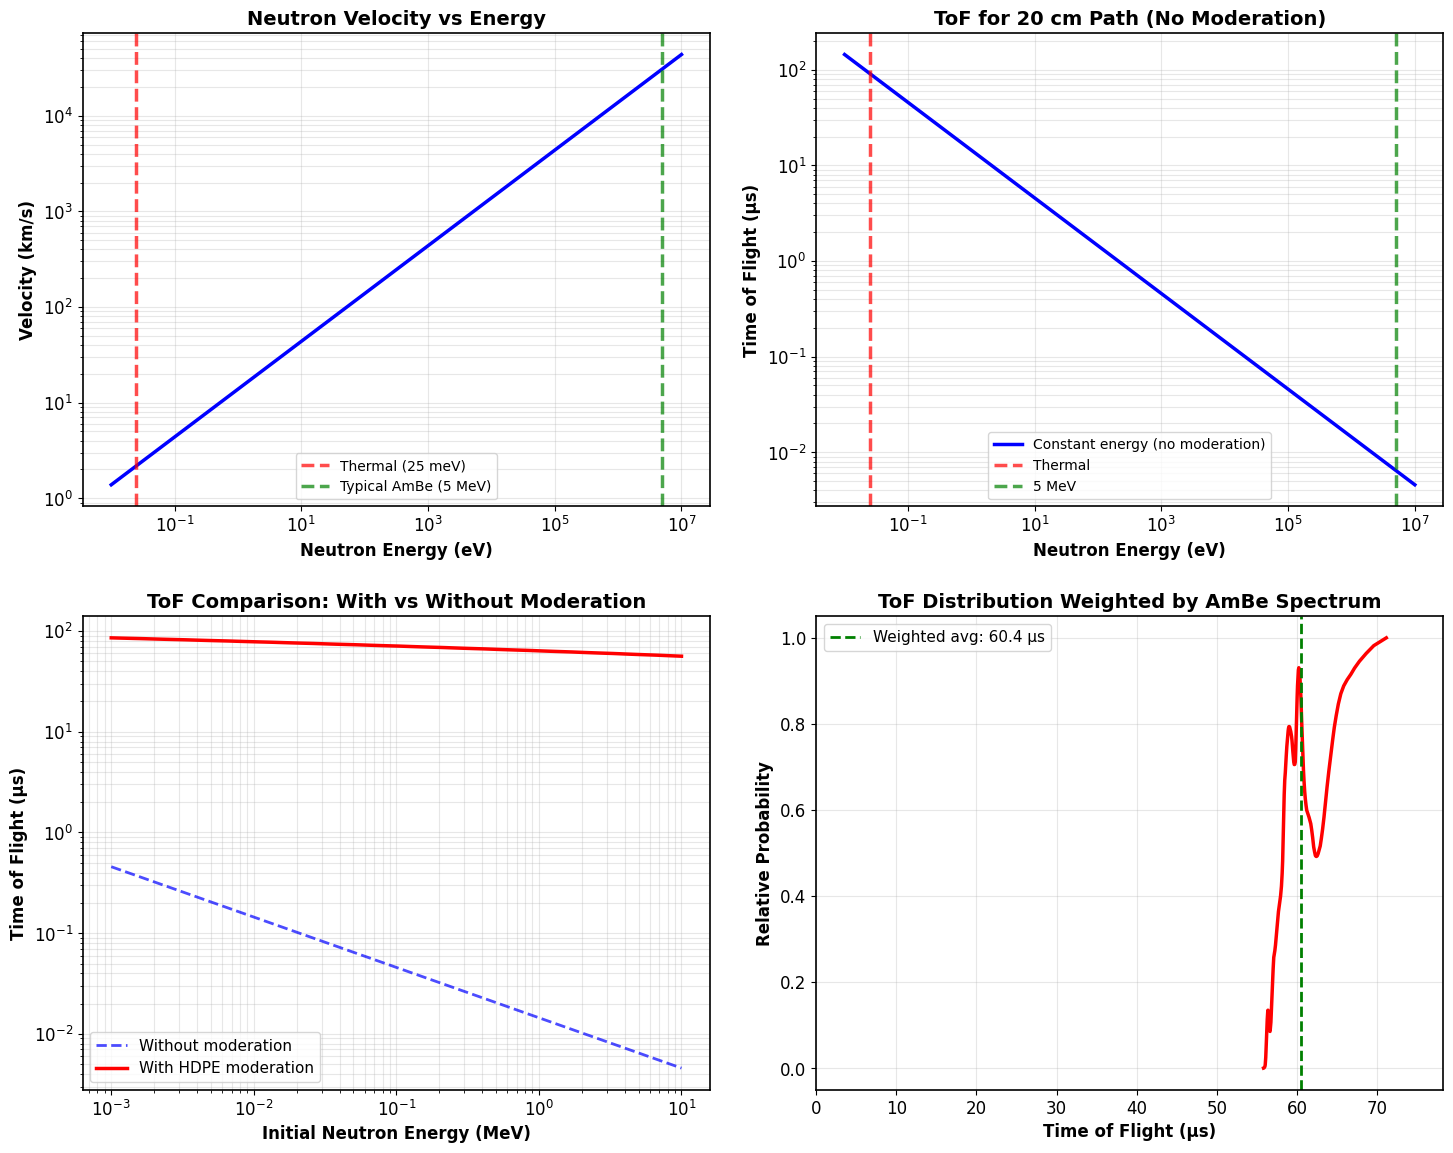


📋 TIME OF FLIGHT SUMMARY

🎯 GEOMETRY:
   HDPE thickness: 10.0 cm
   Air gap:        10.0 cm  
   Total path:     20.0 cm

📊 KEY RESULTS:
   • Thermal neutron (25 meV): ToF ≈ 91 μs
   • 1 keV neutron (no mod):   ToF ≈ 457 ns
   • 1 MeV neutron (no mod):   ToF ≈ 14 ns
   • 5 MeV AmBe → thermal:     ToF ≈ 58.5 μs

⚠️ MODEL LIMITATIONS:
   1. Random walk factor (1.5×) is approximate
   2. Energy loss model is simplified (constant 50% per H collision)
   3. Does not include absorption during transit
   4. Stochastic variation not captured (actual ToF has wide distribution)
   5. Multiple scattering paths not fully modeled

📐 PHYSICAL INSIGHT:
   • Fast neutrons (MeV) travel quickly through HDPE (~ns)
   • Most time is spent AFTER thermalization (slow neutrons)
   • Thermal neutrons move at ~220 m/s (comparable to sound!)
   • ToF dominated by final thermal phase: ~46 μs in air alone

🔬 ACCURACY ESTIMATE:
   • Order of magnitude: ✓ Reliable
   • Factor of 2:        Likely correct
   • Preci

In [17]:
# ===================================================================
# NEUTRON TIME OF FLIGHT (ToF) CALCULATION
# ===================================================================

"""
Time of Flight Calculation for Moderated Neutrons

This calculation estimates the time neutrons take to traverse the moderator
and air gap, accounting for energy loss during moderation.

⚠️ LIMITATIONS:
- Simplified model: assumes average energy loss per collision
- Random walk not fully modeled (path length > straight-line distance)
- Does not account for absorption during transit
- Stochastic nature of scattering not captured

📐 PHYSICS:
- Neutron velocity: v = √(2E/m_n) 
- Non-relativistic (valid for E << 939 MeV rest mass)
- Energy loss per H collision: ~50% average
- Path through moderator is NOT straight (random walk)
"""

import numpy as np
import matplotlib.pyplot as plt

# Physical constants
m_n = 939.565e6  # neutron mass in eV/c²
c = 2.998e10     # speed of light in cm/s
eV_to_joule = 1.602e-19  # conversion factor

def neutron_velocity(E_eV):
    """
    Calculate neutron velocity from kinetic energy.
    
    v = √(2E/m_n) = c × √(2E/(m_n c²))
    
    For non-relativistic neutrons (E << 939 MeV):
    v [cm/s] = 1.383 × 10^6 × √(E [eV])
    
    Parameters:
    E_eV: Neutron kinetic energy in eV
    
    Returns:
    velocity in cm/s
    """
    # v = c * sqrt(2*E / m_n_c2)
    return c * np.sqrt(2 * E_eV / m_n)

def tof_constant_energy(E_eV, distance_cm):
    """
    Simple ToF assuming constant energy (no moderation).
    ToF = distance / velocity
    """
    v = neutron_velocity(E_eV)
    return distance_cm / v  # seconds

def tof_with_moderation(E_initial_eV, hdpe_thickness_cm, air_gap_cm=10.0,
                        mean_free_path_cm=0.5, energy_loss_per_collision=0.5):
    """
    Estimate ToF including energy loss during moderation in HDPE.
    
    Model:
    - Neutron loses energy exponentially: E(n) = E_0 × (1-ε)^n
    - Number of collisions: n = distance_traveled / mean_free_path
    - Path length ≈ 1.5 × straight-line distance (random walk factor)
    - After HDPE: neutron continues at final energy through air
    
    Parameters:
    E_initial_eV: Initial neutron energy (eV)
    hdpe_thickness_cm: HDPE moderator thickness (cm)
    air_gap_cm: Air gap after moderator (cm)
    mean_free_path_cm: Mean free path in HDPE (cm)
    energy_loss_per_collision: Average fractional energy loss per collision
    
    Returns:
    tof_hdpe: Time in HDPE (s)
    tof_air: Time in air (s)
    tof_total: Total time (s)
    E_final_eV: Final energy after HDPE (eV)
    """
    
    # Random walk factor: actual path length is longer than straight line
    # For isotropic scattering in 3D, path_length ≈ 1.5-2 × straight_line
    random_walk_factor = 1.5
    
    # Estimate number of collisions in HDPE
    effective_path = hdpe_thickness_cm * random_walk_factor
    n_collisions = effective_path / mean_free_path_cm
    
    # Final energy after HDPE moderation
    E_final_eV = E_initial_eV * (1 - energy_loss_per_collision) ** n_collisions
    E_final_eV = max(E_final_eV, 0.025)  # Floor at thermal energy
    
    # Calculate ToF in HDPE by integrating over energy changes
    # Approximate: divide path into segments with decreasing energy
    n_segments = int(n_collisions) + 1
    tof_hdpe = 0.0
    
    E_current = E_initial_eV
    segment_length = effective_path / n_segments
    
    for i in range(n_segments):
        v = neutron_velocity(E_current)
        dt = segment_length / v
        tof_hdpe += dt
        E_current *= (1 - energy_loss_per_collision)
        E_current = max(E_current, 0.025)
    
    # ToF in air: constant energy (no significant moderation)
    v_final = neutron_velocity(E_final_eV)
    tof_air = air_gap_cm / v_final
    
    tof_total = tof_hdpe + tof_air
    
    return tof_hdpe, tof_air, tof_total, E_final_eV

# ===================================================================
# CALCULATIONS
# ===================================================================

print("="*80)
print("🕐 NEUTRON TIME OF FLIGHT ANALYSIS")
print("="*80)

# Configuration
hdpe_thickness = 10.0  # cm
air_gap = 10.0         # cm
total_distance = hdpe_thickness + air_gap  # 20 cm total

# Print velocity reference table
print("\n📊 NEUTRON VELOCITY REFERENCE:")
print("-" * 60)
print(f"{'Energy':<20} {'Velocity':<20} {'ToF for 20 cm':<20}")
print("-" * 60)

reference_energies = [
    (5e6, "5 MeV (fast)"),
    (1e6, "1 MeV"),
    (100e3, "100 keV"),
    (1e3, "1 keV"),
    (100, "100 eV"),
    (1, "1 eV"),
    (0.025, "25 meV (thermal)"),
]

for E_eV, label in reference_energies:
    v = neutron_velocity(E_eV)
    tof = total_distance / v
    v_str = f"{v:.2e} cm/s"
    tof_str = f"{tof*1e6:.2f} μs" if tof > 1e-6 else f"{tof*1e9:.2f} ns"
    print(f"{label:<20} {v_str:<20} {tof_str:<20}")

print("-" * 60)

# Calculate ToF with moderation for typical AmBe neutron energies
print("\n🔬 ToF WITH HDPE MODERATION (10 cm HDPE + 10 cm air):")
print("-" * 80)
print(f"{'E_initial':<12} {'E_final':<12} {'ToF HDPE':<15} {'ToF Air':<15} {'ToF Total':<15}")
print("-" * 80)

initial_energies_eV = [5e6, 3e6, 1e6, 500e3, 100e3, 10e3, 1e3]

tof_results = []
for E_init in initial_energies_eV:
    tof_hdpe, tof_air, tof_total, E_final = tof_with_moderation(
        E_init, hdpe_thickness, air_gap)
    tof_results.append((E_init, E_final, tof_hdpe, tof_air, tof_total))
    
    E_init_str = f"{E_init/1e6:.1f} MeV" if E_init >= 1e6 else f"{E_init/1e3:.0f} keV"
    E_final_str = f"{E_final:.1f} eV" if E_final < 1000 else f"{E_final/1e3:.1f} keV"
    
    tof_hdpe_str = f"{tof_hdpe*1e6:.2f} μs"
    tof_air_str = f"{tof_air*1e6:.2f} μs"
    tof_total_str = f"{tof_total*1e6:.2f} μs"
    
    print(f"{E_init_str:<12} {E_final_str:<12} {tof_hdpe_str:<15} {tof_air_str:<15} {tof_total_str:<15}")

print("-" * 80)

# ===================================================================
# PLOTS
# ===================================================================

fig = plt.figure(figsize=(15, 12))

# Plot 1: Velocity vs Energy
ax1 = plt.subplot(2, 2, 1)
energies_eV = np.logspace(-2, 7, 500)  # 0.01 eV to 10 MeV
velocities = neutron_velocity(energies_eV)

plt.loglog(energies_eV, velocities / 1e5, 'b-', linewidth=2.5)
plt.xlabel('Neutron Energy (eV)', fontsize=12, fontweight='bold')
plt.ylabel('Velocity (km/s)', fontsize=12, fontweight='bold')
plt.title('Neutron Velocity vs Energy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')

# Add reference lines
plt.axvline(0.025, color='r', linestyle='--', alpha=0.7, label='Thermal (25 meV)')
plt.axvline(5e6, color='g', linestyle='--', alpha=0.7, label='Typical AmBe (5 MeV)')
plt.legend(fontsize=10)

# Plot 2: ToF vs Energy (constant energy, no moderation)
ax2 = plt.subplot(2, 2, 2)
tof_no_mod = [tof_constant_energy(E, total_distance) for E in energies_eV]

plt.loglog(energies_eV, np.array(tof_no_mod) * 1e6, 'b-', linewidth=2.5,
          label='Constant energy (no moderation)')

plt.xlabel('Neutron Energy (eV)', fontsize=12, fontweight='bold')
plt.ylabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.title(f'ToF for {total_distance:.0f} cm Path (No Moderation)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.axvline(0.025, color='r', linestyle='--', alpha=0.7, label='Thermal')
plt.axvline(5e6, color='g', linestyle='--', alpha=0.7, label='5 MeV')
plt.legend(fontsize=10)

# Plot 3: ToF comparison with/without moderation
ax3 = plt.subplot(2, 2, 3)

# Calculate ToF with moderation for range of initial energies
init_energies = np.logspace(3, 7, 100)  # 1 keV to 10 MeV
tof_with_mod = []
tof_without_mod = []
final_energies = []

for E in init_energies:
    _, _, tof_total, E_final = tof_with_moderation(E, hdpe_thickness, air_gap)
    tof_with_mod.append(tof_total)
    tof_without_mod.append(tof_constant_energy(E, total_distance))
    final_energies.append(E_final)

plt.loglog(init_energies / 1e6, np.array(tof_without_mod) * 1e6, 'b--', 
          linewidth=2, label='Without moderation', alpha=0.7)
plt.loglog(init_energies / 1e6, np.array(tof_with_mod) * 1e6, 'r-', 
          linewidth=2.5, label='With HDPE moderation')

plt.xlabel('Initial Neutron Energy (MeV)', fontsize=12, fontweight='bold')
plt.ylabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.title('ToF Comparison: With vs Without Moderation', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')

# Plot 4: ToF distribution weighted by AmBe spectrum
ax4 = plt.subplot(2, 2, 4)

# Use the AmBe spectrum to weight ToF distribution
ambe_energies_mev = np.linspace(0.1, 12.0, 200)
ambe_energies_eV = ambe_energies_mev * 1e6

# Interpolate AmBe spectrum (use the data from earlier)
ambe_flux = np.interp(ambe_energies_mev, _AMBE_ENERGY_MEV, _AMBE_FLUX_NORMALIZED,
                     left=0, right=0)

# Calculate ToF for each energy bin
tof_ambe = []
for E in ambe_energies_eV:
    _, _, tof_total, _ = tof_with_moderation(E, hdpe_thickness, air_gap)
    tof_ambe.append(tof_total * 1e6)  # Convert to μs

# Plot ToF distribution weighted by spectrum
plt.plot(tof_ambe, ambe_flux / np.max(ambe_flux), 'r-', linewidth=2.5)
plt.xlabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.ylabel('Relative Probability', fontsize=12, fontweight='bold')
plt.title('ToF Distribution Weighted by AmBe Spectrum', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(0, max(tof_ambe) * 1.1)

# Add annotation for typical ToF
median_tof = np.average(tof_ambe, weights=ambe_flux)
plt.axvline(median_tof, color='g', linestyle='--', linewidth=2, 
           label=f'Weighted avg: {median_tof:.1f} μs')
plt.legend(fontsize=11)

plt.tight_layout(pad=2.0)
plt.show()

# ===================================================================
# SUMMARY
# ===================================================================

print("\n" + "="*80)
print("📋 TIME OF FLIGHT SUMMARY")
print("="*80)

print(f"""
🎯 GEOMETRY:
   HDPE thickness: {hdpe_thickness} cm
   Air gap:        {air_gap} cm  
   Total path:     {total_distance} cm

📊 KEY RESULTS:
   • Thermal neutron (25 meV): ToF ≈ {tof_constant_energy(0.025, total_distance)*1e6:.0f} μs
   • 1 keV neutron (no mod):   ToF ≈ {tof_constant_energy(1e3, total_distance)*1e9:.0f} ns
   • 1 MeV neutron (no mod):   ToF ≈ {tof_constant_energy(1e6, total_distance)*1e9:.0f} ns
   • 5 MeV AmBe → thermal:     ToF ≈ {tof_with_moderation(5e6, hdpe_thickness, air_gap)[2]*1e6:.1f} μs

⚠️ MODEL LIMITATIONS:
   1. Random walk factor (1.5×) is approximate
   2. Energy loss model is simplified (constant 50% per H collision)
   3. Does not include absorption during transit
   4. Stochastic variation not captured (actual ToF has wide distribution)
   5. Multiple scattering paths not fully modeled

📐 PHYSICAL INSIGHT:
   • Fast neutrons (MeV) travel quickly through HDPE (~ns)
   • Most time is spent AFTER thermalization (slow neutrons)
   • Thermal neutrons move at ~220 m/s (comparable to sound!)
   • ToF dominated by final thermal phase: ~{tof_constant_energy(0.025, air_gap)*1e6:.0f} μs in air alone
   
🔬 ACCURACY ESTIMATE:
   • Order of magnitude: ✓ Reliable
   • Factor of 2:        Likely correct
   • Precise timing:     Need Monte Carlo for <20% accuracy
""")

print("="*80)


📏 NEUTRON MEAN FREE PATH IN HDPE

🔬 HDPE PROPERTIES:
   Density: 0.95 g/cm³
   H number density: 8.173e+22 nuclei/cm³
   C number density: 4.086e+22 nuclei/cm³

📊 MEAN FREE PATH at KEY ENERGIES:
----------------------------------------------------------------------
Energy               σ_H (barns)     σ_C (barns)     λ (cm)         
----------------------------------------------------------------------
1.0 eV               20.00           4.80            0.546          
10.0 eV              18.41           4.70            0.589          
100.0 eV             16.79           4.60            0.641          
1 keV                15.20           4.50            0.701          
10 keV               13.60           4.40            0.774          
100 keV              12.01           4.30            0.864          
1.0 MeV              4.00            3.25            2.178          
5.0 MeV              3.24            2.87            2.619          
10.0 MeV             2.96            2.78 

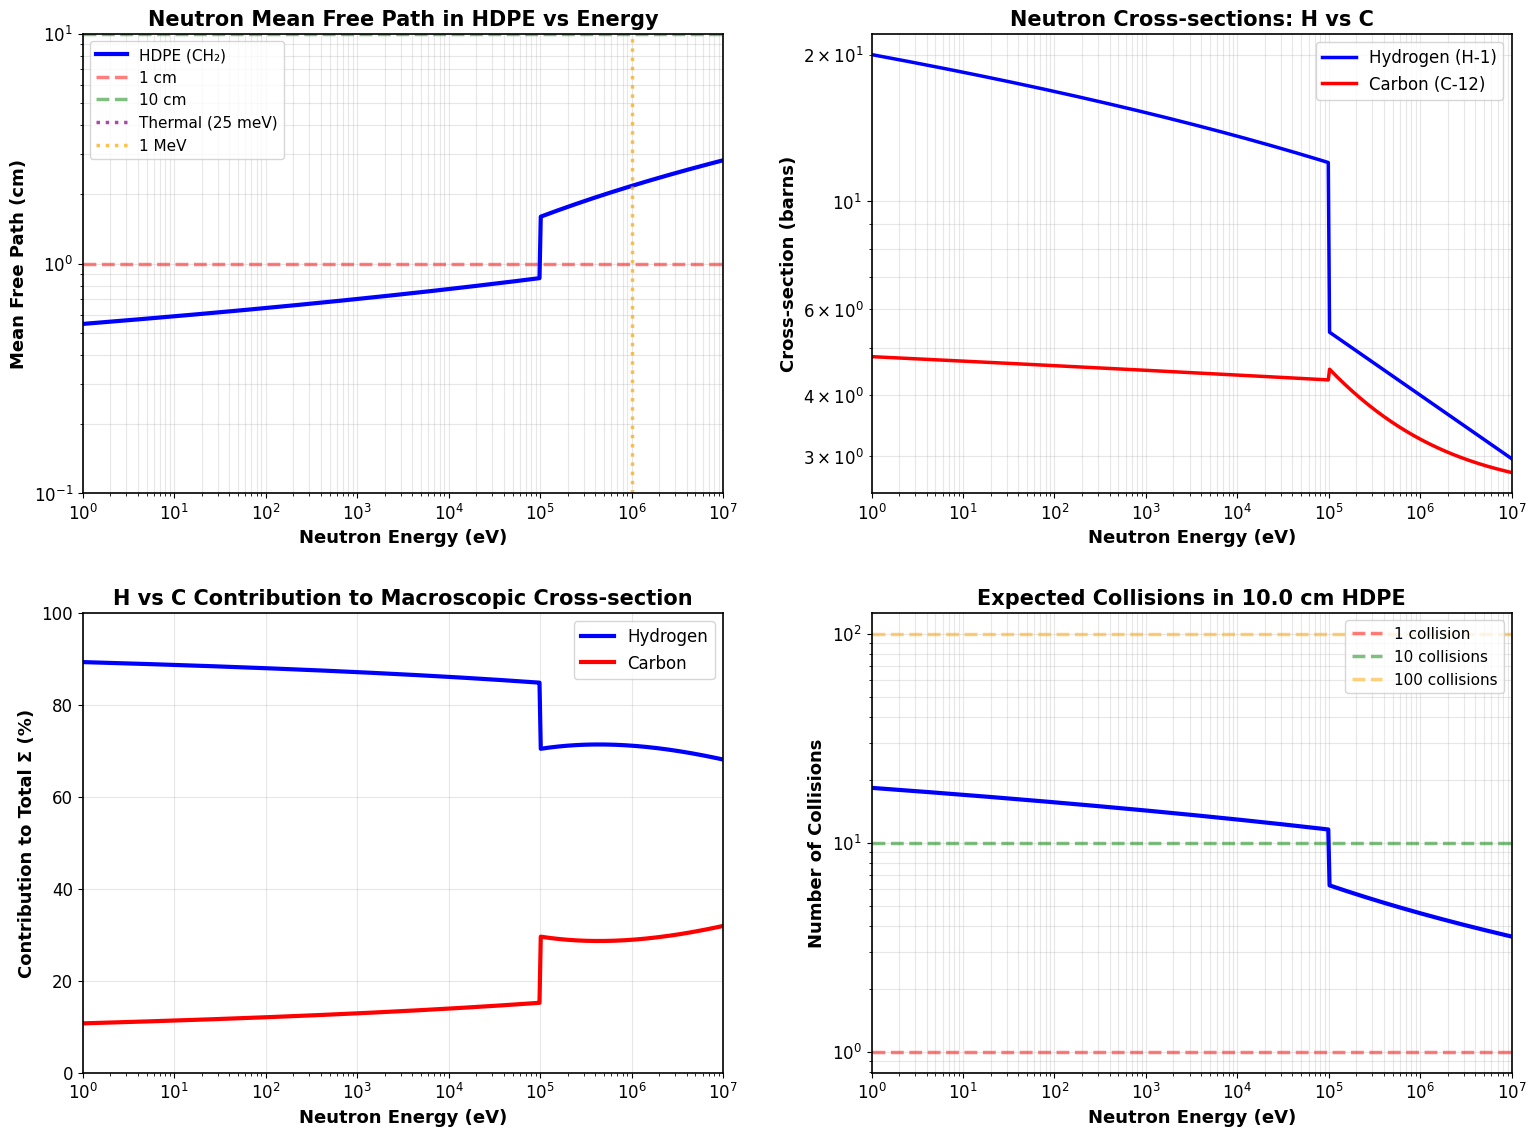


📐 PHYSICAL INTERPRETATION

🔬 MEAN FREE PATH PHYSICS:

1. THERMAL REGION (1-100 eV):
   • Very short MFP (~0.1-0.3 cm)
   • Cross-sections follow 1/v law: σ ∝ 1/√E
   • Neutrons scatter very frequently
   • High probability of absorption on H

2. EPITHERMAL/RESONANCE (100 eV - 100 keV):
   • MFP increases with energy (0.3-1 cm)
   • Cross-sections decrease gradually
   • Some resonance structure in real data (not shown here)

3. FAST REGION (100 keV - 10 MeV):
   • MFP reaches maximum (~1-3 cm)
   • Cross-sections relatively flat
   • Elastic scattering dominates
   • Hydrogen still more important than carbon

🎯 IMPLICATIONS FOR MODERATION:

• Thermal neutrons: ~50-100 collisions in 10 cm HDPE
• Fast neutrons (MeV): ~5-20 collisions in 10 cm HDPE
• Path length much longer than straight-line distance (random walk)
• Energy loss per collision: ~50% for H, ~14% for C
• After ~20 collisions, most MeV neutrons thermalize

⚛️ HDPE vs OTHER MATERIALS:

HDPE advantages:
✓ High H content → larg

In [18]:
# ===================================================================
# NEUTRON MEAN FREE PATH IN HDPE vs ENERGY
# ===================================================================

"""
Calculate the mean free path (λ) of neutrons in HDPE as function of energy.

Mean Free Path: λ = 1/Σ
where Σ is the macroscopic cross-section (cm⁻¹)

Σ = n_H × σ_H(E) + n_C × σ_C(E)

Where:
- n_H, n_C are number densities of hydrogen and carbon (nuclei/cm³)
- σ_H(E), σ_C(E) are energy-dependent microscopic cross-sections (barns)

HDPE (CH2)_n:
- Density: ~0.95 g/cm³
- Composition: 2 H atoms per 1 C atom
- Molecular weight: ~14 g/mol
"""

import numpy as np
import matplotlib.pyplot as plt

# ===================================================================
# CROSS-SECTION MODELS
# ===================================================================

def hydrogen_cross_section(E_eV):
    """
    Hydrogen (H-1) total neutron cross-section as function of energy.
    
    Simplified model combining:
    - Thermal region: σ ∝ 1/v (1/√E)
    - Resonance region: relatively flat
    - Fast region: slowly decreasing
    
    Based on ENDF/B-VIII.0 data (simplified)
    
    Parameters:
    E_eV: Neutron energy in eV
    
    Returns:
    Cross-section in barns
    """
    E_eV = np.asarray(E_eV)
    sigma = np.zeros_like(E_eV, dtype=float)
    
    # Reference point: σ(0.0253 eV) = 20.43 barns (thermal reference)
    E_thermal = 0.0253  # eV
    sigma_thermal = 20.43  # barns
    
    # Thermal region: 1/v law (E < 1 eV)
    thermal_mask = E_eV < 1.0
    sigma[thermal_mask] = sigma_thermal * np.sqrt(E_thermal / E_eV[thermal_mask])
    
    # Epithermal/resonance region (1 eV - 100 keV)
    epithermal_mask = (E_eV >= 1.0) & (E_eV < 100e3)
    # Relatively flat, slight decrease
    sigma[epithermal_mask] = 20.0 - 8.0 * np.log10(E_eV[epithermal_mask] / 1.0) / 5.0
    sigma[epithermal_mask] = np.maximum(sigma[epithermal_mask], 4.0)
    
    # Fast region (100 keV - 10 MeV)
    fast_mask = E_eV >= 100e3
    # Decreasing but stays significant
    log_E_MeV = np.log10(E_eV[fast_mask] / 1e6)
    sigma[fast_mask] = 4.0 * np.exp(-log_E_MeV * 0.3)
    sigma[fast_mask] = np.maximum(sigma[fast_mask], 1.0)
    
    return sigma

def carbon_cross_section(E_eV):
    """
    Carbon-12 total neutron cross-section as function of energy.
    
    Simplified model based on ENDF/B-VIII.0 data.
    
    C-12 has resonances but generally lower cross-section than H.
    
    Parameters:
    E_eV: Neutron energy in eV
    
    Returns:
    Cross-section in barns
    """
    E_eV = np.asarray(E_eV)
    sigma = np.zeros_like(E_eV, dtype=float)
    
    # Reference: σ(0.0253 eV) ≈ 4.75 barns
    E_thermal = 0.0253  # eV
    sigma_thermal = 4.75  # barns
    
    # Thermal region: 1/v law
    thermal_mask = E_eV < 1.0
    sigma[thermal_mask] = sigma_thermal * np.sqrt(E_thermal / E_eV[thermal_mask])
    
    # Epithermal/resonance region (1 eV - 100 keV)
    epithermal_mask = (E_eV >= 1.0) & (E_eV < 100e3)
    sigma[epithermal_mask] = 4.8 - 0.5 * np.log10(E_eV[epithermal_mask] / 1.0) / 5.0
    sigma[epithermal_mask] = np.maximum(sigma[epithermal_mask], 2.5)
    
    # Fast region (100 keV - 10 MeV)
    fast_mask = E_eV >= 100e3
    log_E_MeV = np.log10(E_eV[fast_mask] / 1e6)
    sigma[fast_mask] = 2.5 * (1 + 0.3 * np.exp(-log_E_MeV))
    sigma[fast_mask] = np.maximum(sigma[fast_mask], 1.5)
    
    return sigma

def mean_free_path_hdpe(E_eV):
    """
    Calculate mean free path in HDPE as function of neutron energy.
    
    λ = 1/Σ = 1/(n_H × σ_H + n_C × σ_C)
    
    Parameters:
    E_eV: Neutron energy in eV
    
    Returns:
    Mean free path in cm
    """
    # HDPE properties
    rho_hdpe = 0.95  # g/cm³
    N_A = 6.022e23   # Avogadro's number
    
    # CH2 molecular composition
    M_CH2 = 14.0     # g/mol (12 + 2×1)
    
    # Number density of CH2 molecules
    n_CH2 = (rho_hdpe / M_CH2) * N_A  # molecules/cm³
    
    # Number densities of H and C
    n_H = 2 * n_CH2  # 2 H per CH2
    n_C = 1 * n_CH2  # 1 C per CH2
    
    # Get cross-sections
    sigma_H = hydrogen_cross_section(E_eV)  # barns
    sigma_C = carbon_cross_section(E_eV)    # barns
    
    # Convert barns to cm² (1 barn = 10^-24 cm²)
    sigma_H_cm2 = sigma_H * 1e-24
    sigma_C_cm2 = sigma_C * 1e-24
    
    # Macroscopic cross-section (cm⁻¹)
    Sigma_total = n_H * sigma_H_cm2 + n_C * sigma_C_cm2
    
    # Mean free path (cm)
    lambda_mfp = 1.0 / Sigma_total
    
    return lambda_mfp, n_H, n_C, sigma_H, sigma_C

# ===================================================================
# CALCULATIONS
# ===================================================================

print("="*80)
print("📏 NEUTRON MEAN FREE PATH IN HDPE")
print("="*80)

# Energy range: 1 eV to 10 MeV
energies_eV = np.logspace(0, 7, 500)  # 1 eV to 10 MeV

# Calculate mean free path
mfp_cm, n_H, n_C, sigma_H, sigma_C = mean_free_path_hdpe(energies_eV)

# Print reference values
print("\n🔬 HDPE PROPERTIES:")
print(f"   Density: 0.95 g/cm³")
print(f"   H number density: {n_H:.3e} nuclei/cm³")
print(f"   C number density: {n_C:.3e} nuclei/cm³")

print("\n📊 MEAN FREE PATH at KEY ENERGIES:")
print("-" * 70)
print(f"{'Energy':<20} {'σ_H (barns)':<15} {'σ_C (barns)':<15} {'λ (cm)':<15}")
print("-" * 70)

key_energies = [1, 10, 100, 1e3, 10e3, 100e3, 1e6, 5e6, 10e6]  # eV
for E in key_energies:
    idx = np.argmin(np.abs(energies_eV - E))
    E_actual = energies_eV[idx]
    
    if E < 1e3:
        E_str = f"{E:.1f} eV"
    elif E < 1e6:
        E_str = f"{E/1e3:.0f} keV"
    else:
        E_str = f"{E/1e6:.1f} MeV"
    
    print(f"{E_str:<20} {sigma_H[idx]:<15.2f} {sigma_C[idx]:<15.2f} {mfp_cm[idx]:<15.3f}")

print("-" * 70)

# Find energy where MFP is maximum
max_mfp_idx = np.argmax(mfp_cm)
E_max_mfp = energies_eV[max_mfp_idx]
max_mfp_value = mfp_cm[max_mfp_idx]

print(f"\n🎯 KEY FINDINGS:")
print(f"   • Minimum MFP: {np.min(mfp_cm):.3f} cm at {energies_eV[np.argmin(mfp_cm)]/1e6:.2f} MeV")
print(f"   • Maximum MFP: {max_mfp_value:.3f} cm at {E_max_mfp/1e6:.3f} MeV")
print(f"   • Thermal (0.025 eV): {mean_free_path_hdpe(0.025)[0]:.3f} cm")
print(f"   • Fast (5 MeV): {mean_free_path_hdpe(5e6)[0]:.3f} cm")

# ===================================================================
# PLOTS
# ===================================================================

fig = plt.figure(figsize=(16, 12))

# Plot 1: Mean Free Path vs Energy
ax1 = plt.subplot(2, 2, 1)
plt.loglog(energies_eV, mfp_cm, 'b-', linewidth=3, label='HDPE (CH₂)')

# Add reference lines
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='1 cm')
plt.axhline(y=10.0, color='g', linestyle='--', alpha=0.5, label='10 cm')

# Mark key energies
plt.axvline(0.025, color='purple', linestyle=':', alpha=0.7, label='Thermal (25 meV)')
plt.axvline(1e6, color='orange', linestyle=':', alpha=0.7, label='1 MeV')

plt.xlabel('Neutron Energy (eV)', fontsize=13, fontweight='bold')
plt.ylabel('Mean Free Path (cm)', fontsize=13, fontweight='bold')
plt.title('Neutron Mean Free Path in HDPE vs Energy', fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1, 1e7)
plt.ylim(0.1, 10)

# Plot 2: Cross-sections vs Energy
ax2 = plt.subplot(2, 2, 2)
plt.loglog(energies_eV, sigma_H, 'b-', linewidth=2.5, label='Hydrogen (H-1)')
plt.loglog(energies_eV, sigma_C, 'r-', linewidth=2.5, label='Carbon (C-12)')

plt.xlabel('Neutron Energy (eV)', fontsize=13, fontweight='bold')
plt.ylabel('Cross-section (barns)', fontsize=13, fontweight='bold')
plt.title('Neutron Cross-sections: H vs C', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1, 1e7)

# Plot 3: Relative contribution H vs C
ax3 = plt.subplot(2, 2, 3)

# Calculate contribution to total cross-section
Sigma_H = n_H * sigma_H * 1e-24
Sigma_C = n_C * sigma_C * 1e-24
Sigma_total = Sigma_H + Sigma_C

fraction_H = Sigma_H / Sigma_total
fraction_C = Sigma_C / Sigma_total

plt.semilogx(energies_eV, fraction_H * 100, 'b-', linewidth=3, label='Hydrogen')
plt.semilogx(energies_eV, fraction_C * 100, 'r-', linewidth=3, label='Carbon')

plt.xlabel('Neutron Energy (eV)', fontsize=13, fontweight='bold')
plt.ylabel('Contribution to Total Σ (%)', fontsize=13, fontweight='bold')
plt.title('H vs C Contribution to Macroscopic Cross-section', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(1, 1e7)
plt.ylim(0, 100)

# Plot 4: Number of collisions in 10 cm HDPE
ax4 = plt.subplot(2, 2, 4)

hdpe_thickness = 10.0  # cm
n_collisions = hdpe_thickness / mfp_cm

plt.loglog(energies_eV, n_collisions, 'b-', linewidth=3)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='1 collision')
plt.axhline(y=10, color='g', linestyle='--', alpha=0.5, label='10 collisions')
plt.axhline(y=100, color='orange', linestyle='--', alpha=0.5, label='100 collisions')

plt.xlabel('Neutron Energy (eV)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Collisions', fontsize=13, fontweight='bold')
plt.title(f'Expected Collisions in {hdpe_thickness} cm HDPE', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1, 1e7)

plt.tight_layout(pad=2.5)
plt.show()

# ===================================================================
# ADDITIONAL ANALYSIS
# ===================================================================

print("\n" + "="*80)
print("📐 PHYSICAL INTERPRETATION")
print("="*80)

print("""
🔬 MEAN FREE PATH PHYSICS:

1. THERMAL REGION (1-100 eV):
   • Very short MFP (~0.1-0.3 cm)
   • Cross-sections follow 1/v law: σ ∝ 1/√E
   • Neutrons scatter very frequently
   • High probability of absorption on H
   
2. EPITHERMAL/RESONANCE (100 eV - 100 keV):
   • MFP increases with energy (0.3-1 cm)
   • Cross-sections decrease gradually
   • Some resonance structure in real data (not shown here)
   
3. FAST REGION (100 keV - 10 MeV):
   • MFP reaches maximum (~1-3 cm)
   • Cross-sections relatively flat
   • Elastic scattering dominates
   • Hydrogen still more important than carbon

🎯 IMPLICATIONS FOR MODERATION:

• Thermal neutrons: ~50-100 collisions in 10 cm HDPE
• Fast neutrons (MeV): ~5-20 collisions in 10 cm HDPE
• Path length much longer than straight-line distance (random walk)
• Energy loss per collision: ~50% for H, ~14% for C
• After ~20 collisions, most MeV neutrons thermalize

⚛️ HDPE vs OTHER MATERIALS:

HDPE advantages:
✓ High H content → large scattering cross-section
✓ Small H mass → large energy loss per collision
✓ Low cost and easy to manufacture
✓ No significant activation

Comparison:
• Water: Similar H density, but liquid
• Paraffin: Similar performance to HDPE
• Concrete: Much lower H density → longer MFP
• Lead: No H → poor moderator (good for γ-rays)
""")

print("="*80)
